# **Pitch Clock in Play: Analysis of MLB Pitcher Performance**



**Note: This project was completed in Fall 2024 as group project for SDS 336: Practical Machine Learning. Original Datasets are no longer accessible, so this notebook is presented as record of the original analysis performed for our report and presentation. The notebook has been altered to remove unncessary steps unimportant to analysis performed**

**------------------------------------------------------------------------------------------------------------------**

## **Set Up**

In [22]:
# Imports and installs for Project

import pandas as pd
import numpy as np
!pip install MLB-StatsAPI
!pip install pybaseball
from pybaseball import statcast, playerid_lookup, statcast_pitcher, statcast_batter, pitching_stats, batting_stats, pitching_stats_range, batting_stats_range, pitching_stats_bref, batting_stats_bref
import seaborn as sb
import matplotlib.pyplot as plt

## **Seperate Years**

In [23]:
# View all columns in wide view of data
pd.set_option('display.max_columns', None)

In [24]:
# Note: Version of file for this project could not be recovered
data = pd.read_csv('FullStatcast.csv')

In [ ]:
#All steps done to prep the dataset. Feel free to add more
df = data
newColNames = ['pitch_type', 'game_date', 'pitch_velo', 'horizontal_release_pos',
       'vertical_release_pos', 'player_name', 'batter_id', 'pitcher_id', 'events',
       'description', 'spin_dir_deprecated', 'spin_rate_deprecated',
       'break_angle_deprecated', 'break_length_deprecated', 'zone_location', 'gameday_desc',
       'game_type', 'batter_stand', 'p_handedness', 'home_team', 'away_team', 'type',
       'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'horizontal_movement',
       'vertical_movement', 'plate_horizontal', 'plate_vertical', 'on_3b', 'on_2b', 'on_1b',
       'outs_when_up', 'inning', 'inning_topbot', 'hitcord_x', 'hitcord_y',
       'tfs_deprecated', 'tfs_zulu_deprecated', 'catcher_id', 'umpire_deprecated', 'sv_id',
       'velo_x0', 'velo_y0', 'velo_z0', 'accel_x', 'accel_y', 'accel_z', 'sz_top', 'sz_bot',
       'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed',
       'release_spin_rate', 'release_extension', 'game_id', 'pitcher.1',
       'fielder_2.1', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6',
       'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y',
       'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle',
       'woba_value', 'woba_denom', 'babip_value', 'iso_value',
       'launch_speed_angle', 'at_bat_number', 'pitch_number', 'pitch_name',
       'home_score', 'away_score', 'bat_score', 'fld_score', 'post_away_score',
       'post_home_score', 'post_bat_score', 'post_fld_score',
       'if_fielding_alignment', 'of_fielding_alignment', 'spin_axis',
       'delta_home_win_exp', 'delta_run_exp', 'bat_speed', 'swing_length']

df.columns = newColNames

naVals = df.isnull().sum().sort_values(ascending=False)
naCols = naVals[naVals == len(df)].index.tolist()
df.drop(naCols, axis = 1, inplace = True)

df['game_type'].unique()
df = df[df['game_type'] == 'R']

df['events'] = df['events'].fillna('pitch_thrown')

df.shape

<ipython-input-4-2d75046e628a>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['events'] = df['events'].fillna('pitch_thrown')


(1422092, 84)

In [ ]:
PrePitchClock = df[df['game_year'] == 2022] #All pitches from the 2022 Season
PrePitchClock_Events = PrePitchClock[PrePitchClock['events'] != 'pitch_thrown'] #All specific events that arent simple pitches thrown
PrePitchClock_Strikes = PrePitchClock[PrePitchClock['type'] == 'S'] #All pitches that result in strike
PrePitchClock_balls = PrePitchClock[PrePitchClock['type'] == 'B'] #All pitches that result in balls
PrePitchClock_inplay = PrePitchClock[PrePitchClock['type'] == 'X'] #All pitches that resuled in in play balls


In [ ]:
PostPitchClock = df[df['game_year'] == 2023] #All pitches from the 2023 Season
PostPitchClock_Events = PostPitchClock[PostPitchClock['events'] != 'pitch_thrown'] #All specific events that arent simple pitches thrown
PostPitchClock_Strikes = PostPitchClock[PostPitchClock['type'] == 'S'] #All pitches that result in strike
PostPitchClock_balls = PostPitchClock[PostPitchClock['type'] == 'B'] #All pitches that result in balls
PostPitchClock_inplay = PostPitchClock[PostPitchClock['type'] == 'X'] #All pitches that resuled in in play balls

In [ ]:
pitchers_2022 = pitching_stats_range('2022-04-01', '2022-10-02')
pitchers_2023 = pitching_stats_range('2023-03-30', '2023-10-01')
batters_2022 = batting_stats_range('2022-04-01', '2022-10-02')
batters_2023 = batting_stats_range('2023-03-30', '2023-10-01')

pitchers_2022 = pitchers_2022[pitchers_2022['IP'] >= 30.0]
pitchers_2023 = pitchers_2023[pitchers_2023['IP'] >= 30.0]
batters_2022 = batters_2022[batters_2022['PA'] >= 200]
batters_2023 = batters_2023[batters_2023['PA'] >= 200]

pitchers_2022.shape, pitchers_2023.shape, batters_2022.shape, batters_2023.shape

((464, 41), (476, 41), (355, 28), (362, 28))

In [ ]:
pitchclock_infractions = pd.read_csv('pitch_timer_infractions.csv')

In [ ]:
pitcher_advanced_2022 = pd.read_csv('2022_Pitcher_Advanced.csv')
pitcher_advanced_2023 = pd.read_csv('2023_Pitcher_Advanced.csv')
pitcher_advanced_2022 = pitcher_advanced_2022[pitcher_advanced_2022['p_formatted_ip'] >= 30.0]
pitcher_advanced_2023 = pitcher_advanced_2023[pitcher_advanced_2023['p_formatted_ip'] >= 30.0]

## **Balls, Strikes and In-Play between 2022 and 2023**

In [ ]:
PrePitchClock['game_date'] = pd.to_datetime(PrePitchClock['game_date'], format = '%Y-%m-%d')
PrePitchClock['month'] = PrePitchClock['game_date'].dt.month
outcome_counts_2022 = PrePitchClock.groupby(['month', 'type']).size().unstack()

plt.figure(figsize = (12,6))
outcome_counts_2022.plot(kind='bar')
plt.title("Counts of Balls (B), Strikes (S), and In-Play (X) per Month (2022)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.legend(title="Outcome")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert game dates to datetime and extract the month
PrePitchClock['game_date'] = pd.to_datetime(PrePitchClock['game_date'], format='%Y-%m-%d')
PrePitchClock['month'] = PrePitchClock['game_date'].dt.month

# Group by month and outcome type, then count occurrences for each outcome
outcome_counts_2022 = PrePitchClock.groupby(['month', 'type']).size().unstack(fill_value=0)

# Debugging step: Print outcome_counts_2022 to check its structure
print(outcome_counts_2022)

# Now, let's create the plot
if not outcome_counts_2022.empty:
    # Set the figure size
    plt.figure(figsize=(12, 6))

    # Create the bar plot with specific colors for each outcome
    outcome_counts_2022.plot(kind='bar', color=['blue', 'red', 'green'], width=0.8)

    # Change the title to be more descriptive
    plt.title("Monthly Counts of Balls, Strikes, and In-Play Outcomes (2022)", fontsize=14)

    # Update x-axis to show month names (April - September only)
    months = ['April', 'May', 'June', 'July', 'August', 'September']
    plt.xticks(ticks=range(3, 9), labels=months, rotation=0)

    # Update y-axis to display counts with increments of 10
    plt.yticks(range(0, int(outcome_counts_2022.values.max()) + 1, 10))
    plt.ylabel("Count of Outcomes (in 10s)", fontsize=12)

    # Make y-axis grid lines more subtle
    plt.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

    # Change the legend to show full labels instead of 'B', 'S', and 'X'
    plt.legend(title="Outcome", labels=['Balls', 'Strikes', 'In Play'])

    # Show the plot
    plt.tight_layout()
    plt.show()
else:
    print("The DataFrame is empty after the groupby operation.")


Empty DataFrame
Columns: []
Index: []
The DataFrame is empty after the groupby operation.


In [ ]:
outcome_counts_2022.mean()

,0
type,
B,36192.714286
S,47274.857143
X,17752.428571


<ipython-input-17-960de93388d0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PostPitchClock['game_date'] = pd.to_datetime(PostPitchClock['game_date'], format = '%Y-%m-%d')
<ipython-input-17-960de93388d0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PostPitchClock['month'] = PostPitchClock['game_date'].dt.month


<Figure size 1200x600 with 0 Axes>

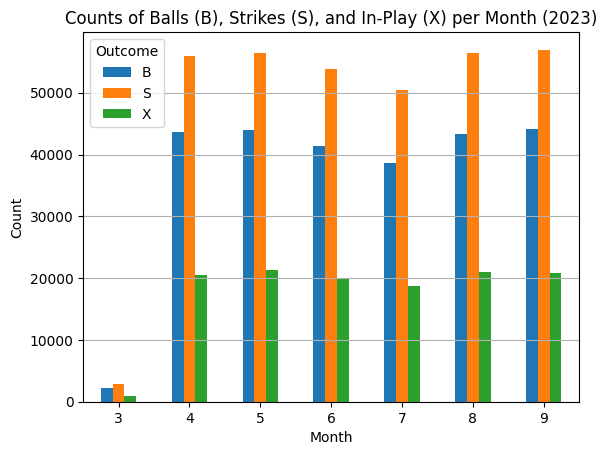

In [ ]:
PostPitchClock['game_date'] = pd.to_datetime(PostPitchClock['game_date'], format = '%Y-%m-%d')
PostPitchClock['month'] = PostPitchClock['game_date'].dt.month
outcome_counts_2023 = PostPitchClock.groupby(['month', 'type']).size().unstack()

plt.figure(figsize = (12,6))
outcome_counts_2023.plot(kind='bar')
plt.title("Counts of Balls (B), Strikes (S), and In-Play (X) per Month (2023)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.legend(title="Outcome")

In [ ]:
outcome_counts_2023.mean()

,0
type,
B,36738.857143
S,47554.428571
X,17642.714286


## **ERA (Earned Runs Allowed) between years**

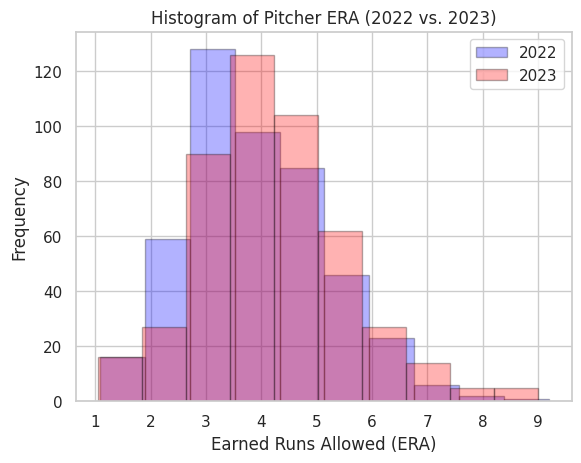

In [ ]:

plt.hist(pitchers_2022['ERA'], alpha=0.3, label='2022', color='blue', edgecolor='black')
plt.hist(pitchers_2023['ERA'], alpha=0.3, label='2023', color='red', edgecolor='black')

plt.title('Histogram of Pitcher ERA (2022 vs. 2023)')
plt.xlabel('Earned Runs Allowed (ERA)')
plt.ylabel('Frequency')


plt.legend()
plt.show()


<ipython-input-56-b8a430848a09>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='Year', y='ERA', data=combined_df, palette="Set1")


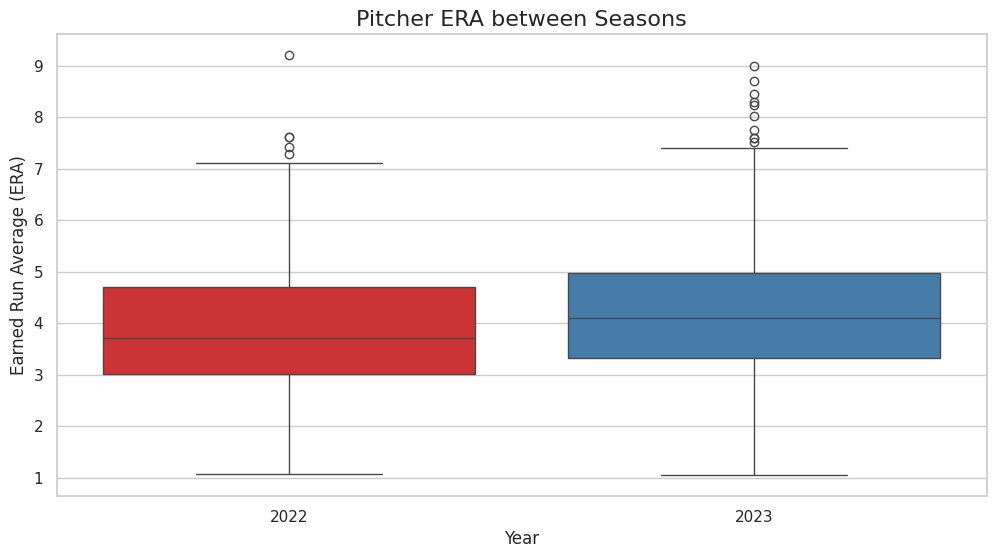

In [ ]:
df_2022 = pd.DataFrame({'ERA' : pitchers_2022['ERA']})
df_2023 = pd.DataFrame({'ERA' : pitchers_2023['ERA']})
df_2022['Year'] = '2022'
df_2023['Year'] = '2023'
combined_df = pd.concat([df_2022, df_2023])

sb.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sb.boxplot(x='Year', y='ERA', data=combined_df, palette="Set1")
plt.title('Pitcher ERA between Seasons', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Earned Run Average (ERA)', fontsize=12)
plt.show()


In [ ]:
pitchers_2022['ERA'].describe()

,ERA
count,464.000000
mean,3.893513
std,1.262968
min,1.080000
25%,3.010000
50%,3.710000
75%,4.702500
max,9.200000


In [ ]:
pitchers_2023['ERA'].describe()

,ERA
count,476.000000
mean,4.213739
std,1.312676
min,1.050000
25%,3.327500
50%,4.095000
75%,4.972500
max,9.000000


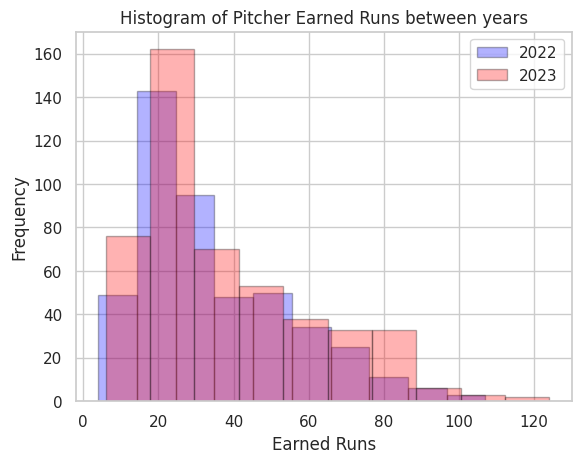

In [ ]:
plt.hist(pitchers_2022['ER'], alpha=0.3, label='2022', color='blue', edgecolor='black')
plt.hist(pitchers_2023['ER'], alpha=0.3, label='2023', color='red', edgecolor='black')

plt.title('Histogram of Pitcher Earned Runs between years')
plt.xlabel('Earned Runs')
plt.ylabel('Frequency')


plt.legend()
plt.show()

In [ ]:
pitchers_2023['ER'].sum()

18044

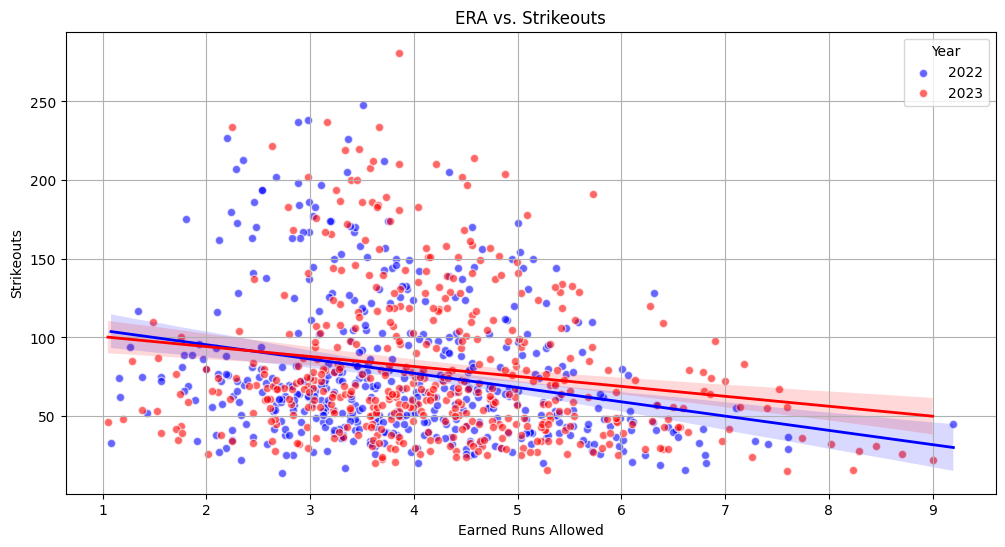

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(
    pitchers_2022['ERA'],
    pitchers_2022['SO'],
    color='blue',
    label='2022',
    alpha=0.6,
    edgecolors='w'
)

# Plot data for 2023
plt.scatter(
    pitchers_2023['ERA'],
    pitchers_2023['SO'],
    color='red',
    label='2023',
    alpha=0.6,
    edgecolors='w'
)
sb.regplot(
    x='ERA',
    y='SO',
    data=pitchers_2022,
    scatter=False,
    color='blue',
    line_kws={'label': '2022 Regression', 'linewidth': 2}
)

# Regression line for 2023 data
sb.regplot(
    x='ERA',
    y='SO',
    data=pitchers_2023,
    scatter=False,
    color='red',
    line_kws={'label': '2023 Regression', 'linewidth': 2}
)



plt.title('ERA vs. Strikeouts')
plt.xlabel('Earned Runs Allowed')
plt.ylabel('Strikeouts')
plt.legend(title='Year')
plt.grid()
plt.show()

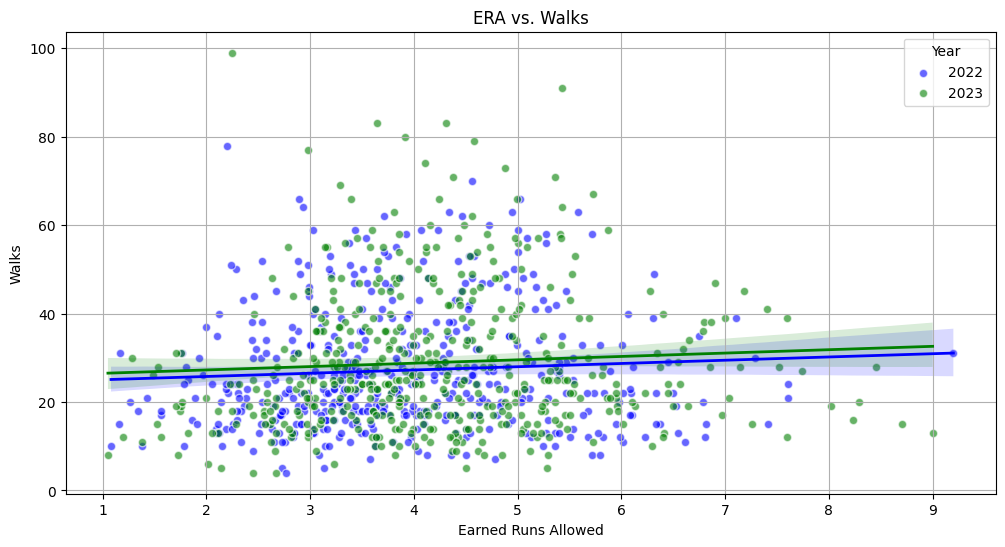

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(
    pitchers_2022['ERA'],
    pitchers_2022['BB'],
    color='blue',
    label='2022',
    alpha=0.6,
    edgecolors='w'
)

# Plot data for 2023
plt.scatter(
    pitchers_2023['ERA'],
    pitchers_2023['BB'],
    color='green',
    label='2023',
    alpha=0.6,
    edgecolors='w'
)
sb.regplot(
    x='ERA',
    y='BB',
    data=pitchers_2022,
    scatter=False,
    color='blue',
    line_kws={'label': '2022 Regression', 'linewidth': 2}
)

# Regression line for 2023 data
sb.regplot(
    x='ERA',
    y='BB',
    data=pitchers_2023,
    scatter=False,
    color='green',
    line_kws={'label': '2023 Regression', 'linewidth': 2}
)

plt.title('ERA vs. Walks')
plt.xlabel('Earned Runs Allowed')
plt.ylabel('Walks')
plt.legend(title='Year')
plt.grid()
plt.show()

##**Hit Outcomes**

In [ ]:
df_2022 = PrePitchClock_Events.groupby('events').size().reset_index(name='Count')
df_2023 = PostPitchClock_Events.groupby('events').size().reset_index(name='Count')
df_2022['Year'] = '2022'
df_2023['Year'] = '2023'

combined_df = pd.concat([df_2022, df_2023], ignore_index=True)
pivot_df = combined_df.pivot_table(index='events', columns='Year', values='Count', fill_value=0)
pivot_df = pivot_df.reset_index()

print(pivot_df)

Year                     events     2022     2023
0                catcher_interf     74.0     96.0
1                        double   7940.0   8184.0
2                   double_play    397.0    390.0
3                   field_error   1138.0   1059.0
4                     field_out  73564.0  72105.0
5               fielders_choice    383.0    373.0
6           fielders_choice_out    282.0    286.0
7                     force_out   3828.0   3583.0
8     grounded_into_double_play   3381.0   3439.0
9                  hit_by_pitch   2045.0   2096.0
10                     home_run   5215.0   5841.0
11                     sac_bunt    390.0    425.0
12                      sac_fly   1202.0   1200.0
13          sac_fly_double_play     22.0     24.0
14                       single  25876.0  25884.0
15                    strikeout  40691.0  41394.0
16        strikeout_double_play    121.0     99.0
17                       triple    643.0    705.0
18                  triple_play      6.0      1.0


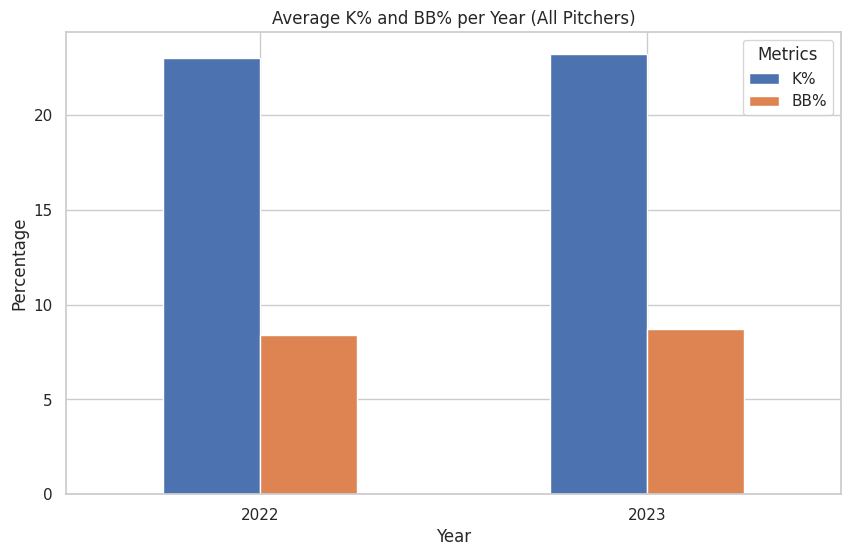

In [ ]:
avg_2022 = {
    'Year': '2022',
    'K%': pitcher_advanced_2022['k_percent'].mean(),
    'BB%': pitcher_advanced_2022['bb_percent'].mean()
}
avg_2023 = {
    'Year': '2023',
    'K%': pitcher_advanced_2023['k_percent'].mean(),
    'BB%': pitcher_advanced_2023['bb_percent'].mean()
}


avg_df = pd.DataFrame([avg_2022, avg_2023])
avg_df.set_index('Year', inplace=True)


avg_df.plot(kind='bar', figsize=(10, 6))
plt.title('Average K% and BB% per Year (All Pitchers)')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(True, axis='y')
plt.show()


In [ ]:
pitcher_advanced_2022['bb_percent'].mean(), pitcher_advanced_2023['bb_percent'].mean()

(8.427021276595744, 8.700420168067225)

##**Pitch Velocity and Exit Velocity**

<ipython-input-112-f2caa155fe19>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='Year', y='EV', data=combined_df, palette="Set1")


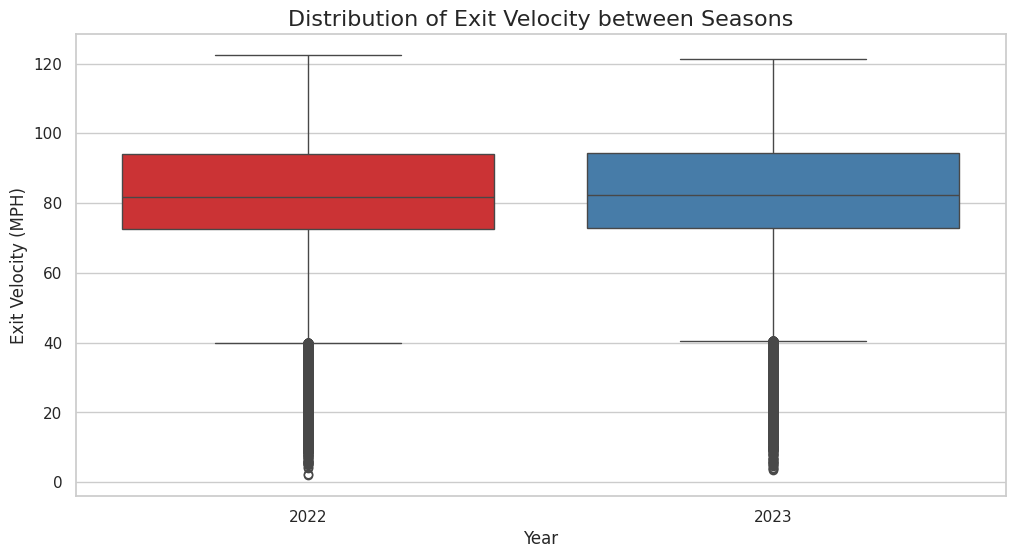

In [ ]:
df_2022 = pd.DataFrame({'EV' : PrePitchClock['launch_speed']})
df_2023 = pd.DataFrame({'EV' : PostPitchClock['launch_speed']})
df_2022['Year'] = '2022'
df_2023['Year'] = '2023'
combined_df = pd.concat([df_2022, df_2023])

sb.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sb.boxplot(x='Year', y='EV', data=combined_df, palette="Set1")
plt.title('Distribution of Exit Velocity between Seasons', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Exit Velocity (MPH)', fontsize=12)
plt.show()


In [ ]:
PrePitchClock['launch_speed'].describe()

,launch_speed
count,235508.000000
mean,82.249762
std,15.278045
min,2.000000
25%,72.500000
50%,81.900000
75%,94.200000
max,122.400000


In [ ]:
PostPitchClock['launch_speed'].describe()

,launch_speed
count,235509.000000
mean,82.602022
std,15.223448
min,3.600000
25%,72.900000
50%,82.200000
75%,94.500000
max,121.200000


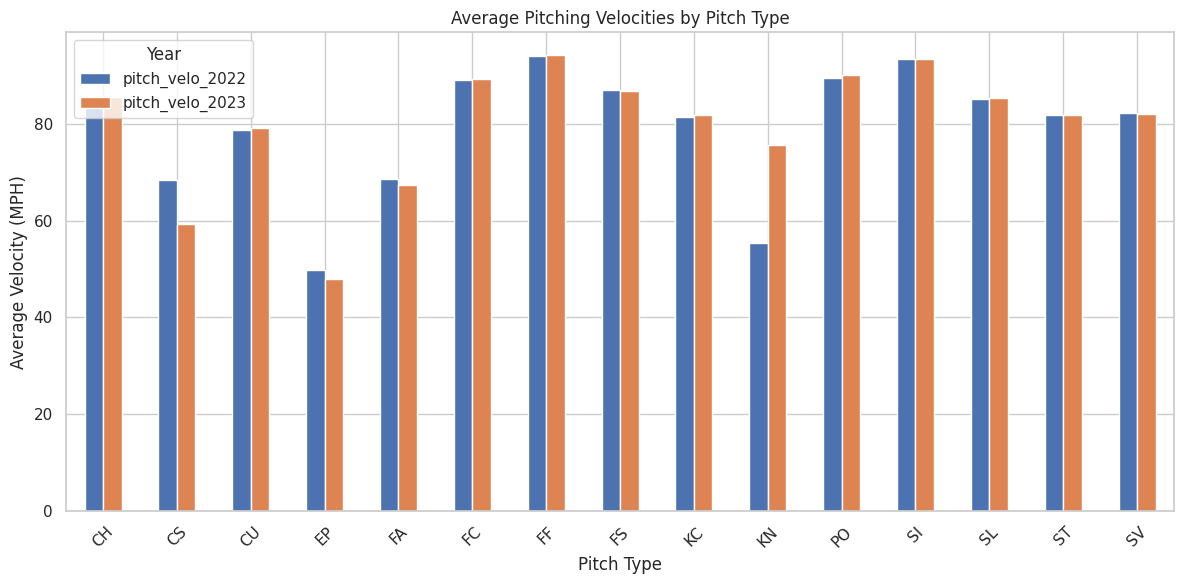

In [ ]:
avg_velocity_2022 = PrePitchClock.groupby('pitch_type')['pitch_velo'].mean().reset_index()
avg_velocity_2023 = PostPitchClock.groupby('pitch_type')['pitch_velo'].mean().reset_index()


avg_velocity_combined = pd.merge(avg_velocity_2022, avg_velocity_2023, on='pitch_type', suffixes=('_2022', '_2023'))
avg_velocity_combined.set_index('pitch_type', inplace=True)


avg_velocity_combined.plot(kind='bar', figsize=(12, 6))
plt.title('Average Pitching Velocities by Pitch Type')
plt.xlabel('Pitch Type')
plt.ylabel('Average Velocity (MPH)')
plt.xticks(rotation=45)
plt.legend(title='Year')

# Show grid
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
PrePitchClock

,pitch_type,game_date,pitch_velo,horizontal_release_pos,vertical_release_pos,player_name,batter_id,pitcher_id,events,description,zone_location,gameday_desc,game_type,batter_stand,p_handedness,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,horizontal_movement,vertical_movement,plate_horizontal,plate_vertical,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hitcord_x,hitcord_y,catcher_id,velo_x0,velo_y0,velo_z0,accel_x,accel_y,accel_z,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_id,pitcher.1,fielder_2.1,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,month
766567,CH,2022-10-05,80.8,-0.76,6.61,"Baker, Bryan",624415,641329,field_out,hit_into_play,4.0,Cavan Biggio flies out to shortstop Jorge Mateo.,R,L,R,BAL,TOR,X,6.0,fly_ball,0,0,2022,-1.34,0.80,-0.32,2.24,NaN,NaN,NaN,2,9,Top,132.96,110.11,668939,3.558407,-117.646983,-4.681001,-13.171122,21.657751,-24.034138,3.37,1.58,225.0,75.9,50.0,81.5,1771.0,6.7,663451,641329,668939,663624,679631,683002,622761,663630,656775,669720,53.85,0.089,0.088,0.0,1.0,0.0,0.0,3.0,78,1,Changeup,5,4,4,5,4,5,4,5,Infield shift,Standard,213.0,0.035,-0.099,10
766568,FF,2022-10-05,97.7,-0.58,6.60,"Baker, Bryan",643376,641329,strikeout,swinging_strike,5.0,Danny Jansen strikes out swinging.,R,R,R,BAL,TOR,S,2.0,NaN,2,2,2022,-0.17,1.58,0.10,2.59,NaN,NaN,NaN,1,9,Top,NaN,NaN,668939,2.238826,-142.091777,-8.968560,-2.851911,33.061824,-8.887788,3.21,1.51,NaN,NaN,NaN,98.1,2434.0,6.6,663451,641329,668939,663624,679631,683002,622761,663630,656775,669720,53.90,NaN,0.000,0.0,1.0,0.0,0.0,NaN,77,5,4-Seam Fastball,5,4,4,5,4,5,4,5,Standard,Standard,189.0,0.052,-0.134,10
766569,CH,2022-10-05,84.9,-0.55,6.58,"Baker, Bryan",643376,641329,pitch_thrown,ball,12.0,Danny Jansen strikes out swinging.,R,R,R,BAL,TOR,B,NaN,NaN,1,2,2022,-1.22,0.83,1.35,2.31,NaN,NaN,NaN,1,9,Top,NaN,NaN,668939,6.936655,-123.422405,-5.325648,-13.889678,25.079523,-22.776142,3.13,1.38,NaN,NaN,NaN,85.2,1856.0,6.6,663451,641329,668939,663624,679631,683002,622761,663630,656775,669720,53.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77,4,Changeup,5,4,4,5,4,5,4,5,Standard,Standard,212.0,0.000,0.023,10
766570,FF,2022-10-05,97.2,-0.42,6.60,"Baker, Bryan",643376,641329,pitch_thrown,swinging_strike,4.0,Danny Jansen strikes out swinging.,R,R,R,BAL,TOR,S,NaN,NaN,1,1,2022,-0.13,1.74,-0.55,2.30,NaN,NaN,NaN,1,9,Top,NaN,NaN,668939,-0.055174,-141.325311,-10.022382,-1.712935,33.111733,-6.725581,3.21,1.51,NaN,NaN,NaN,97.5,2258.0,6.6,663451,641329,668939,663624,679631,683002,622761,663630,656775,669720,53.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77,3,4-Seam Fastball,5,4,4,5,4,5,4,5,Standard,Standard,192.0,0.000,-0.036,10
766571,SL,2022-10-05,86.2,-0.55,6.64,"Baker, Bryan",643376,641329,pitch_thrown,called_strike,3.0,Danny Jansen strikes out swinging.,R,R,R,BAL,TOR,S,NaN,NaN,1,0,2022,0.63,0.00,0.36,3.00,NaN,NaN,NaN,1,9,Top,NaN,NaN,668939,0.906464,-125.636009,-2.473559,6.513804,24.352439,-31.861988,3.13,1.51,NaN,NaN,NaN,86.7,2348.0,6.4,663451,641329,668939,663624,679631,683002,622761,663630,656775,669720,54.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77,2,Slider,5,4,4,5,4,5,4,5,Standard,Standard,127.0,0.000,-0.031,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475102,FS,2022-04-07,91.8,-1.76,6.04,"Ohtani, Shohei",514888,660271,strikeout,called_strike,

##**Pitch Timer Infractions**

In [ ]:
pitchclock_infractions['timer_percentage'] = (pitchclock_infractions['pitcher_timer'] / pitchclock_infractions['pitches']) * 100
pitchclock_infractions[['entity_name', 'pitches', 'pitcher_timer']]


,entity_name,pitches,pitcher_timer
0,Mets,48142,36
1,Rays,47573,36
2,Pirates,48142,41
3,Marlins,47626,29
4,Padres,49046,30
5,Angels,48925,34
6,Astros,51255,27
7,Yankees,47597,37
8,Brewers,48730,28
9,Giants,47229,30


from matplotlib import pyplot as plt
_df_11['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_12['pitches'].plot(kind='hist', bins=20, title='pitches')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_13['pitcher_timer'].plot(kind='hist', bins=20, title='pitcher_timer')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_14.plot(kind='scatter', x='index', y='pitches', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['pitcher_timer']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_17.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('pitcher_timer')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_18.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_19['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_20['pitches'].plot(kind='line', figsize=(8, 4), title='pitches')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_21['pitcher_timer'].plot(kind='line', figsize=(8, 4), title='pitcher_timer')
plt.gca().spines[['top', 'right']].set_visible(False)

# **Incorporation of Model**

Just from what we have learned and prior knowledge, the best way to go about this would be to use a classification model. With that, I think the use of a Random Forest (Multiple Decision Trees) would be the best use of a ML model for this particular problem. Naive Bayes would not be of help here since it would assume each attribute (Stats and measurements) are independent of each other, while KNN only seems to place more emphasis on the similarities between data points, making it difficult to identify differences and identify where differences are in terms of the stats

The idea here is that random forest would allow us to generate a set of Decision Trees that could help us classify based on the stats we provided and decide what is of more importance in these classifications. Knowing which attributes are of more importance could allow us to also evaluate where more analysis can be done. We can also see non linear relationships, avoid overfitting and handle high deimensionality better

In [ ]:
cols_to_keep = [
    'pitch_type', 'game_date', 'pitch_velo', 'horizontal_release_pos', 'vertical_release_pos',
    'player_name', 'batter_id', 'pitcher_id', 'events', 'description', 'type', 'game_year',
    'horizontal_movement', 'vertical_movement', 'plate_horizontal', 'plate_vertical',
    'release_spin_rate', 'release_extension', 'spin_axis', 'p_handedness', 'batter_stand',
    'hit_location', 'bb_type', 'launch_speed', 'launch_angle', 'estimated_ba_using_speedangle',
    'estimated_woba_using_speedangle', 'outs_when_up', 'inning', 'inning_topbot'
]
df_filtered = df[cols_to_keep]

df_filtered

,pitch_type,game_date,pitch_velo,horizontal_release_pos,vertical_release_pos,player_name,batter_id,pitcher_id,events,description,type,game_year,horizontal_movement,vertical_movement,plate_horizontal,plate_vertical,release_spin_rate,release_extension,spin_axis,p_handedness,batter_stand,hit_location,bb_type,launch_speed,launch_angle,estimated_ba_using_speedangle,estimated_woba_using_speedangle,outs_when_up,inning,inning_topbot
0,FF,2023-09-30,96.1,-2.08,5.57,"Smith, Drew",664761,622098,field_out,hit_into_play,X,2023,-0.55,1.64,-1.20,3.23,2479.0,6.0,212.0,R,R,5.0,popup,58.8,70.0,0.001,0.0,2,9,Top
1,FF,2023-09-30,96.5,-1.94,5.59,"Smith, Drew",664761,622098,pitch_thrown,foul,S,2023,-0.70,1.54,0.04,2.80,2386.0,6.0,209.0,R,R,NaN,NaN,76.4,24.0,NaN,NaN,2,9,Top
2,SL,2023-09-30,86.6,-1.91,5.54,"Smith, Drew",664761,622098,pitch_thrown,ball,B,2023,0.48,-0.11,1.24,1.57,2610.0,6.0,114.0,R,R,NaN,NaN,NaN,NaN,NaN,NaN,2,9,Top
3,SL,2023-09-30,87.1,-2.01,5.55,"Smith, Drew",664761,622098,pitch_thrown,swinging_strike,S,2023,0.68,0.07,0.16,0.55,2776.0,6.1,108.0,R,R,NaN,NaN,NaN,NaN,NaN,NaN,2,9,Top
4,FF,2023-09-30,95.9,-2.10,5.51,"Smith, Drew",664761,622098,pitch_thrown,foul,S,2023,-0.78,1.62,-0.29,3.51,2693.0,6.0,215.0,R,R,NaN,NaN,81.2,11.0,NaN,NaN,2,9,Top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475102,FS,2022-04-07,91.8,-1.76,6.04,"Ohtani, Shohei",514888,660271,strikeout,called_strike,S,2022,-0.30,0.08,-0.89,2.05,1314.0,7.0,234.0,R,R,2.0,NaN,NaN,NaN,NaN,0.0,0,1,Top
1475103,ST,2022-04-07,86.9,-2.29,5.77,"Ohtani, Shohei",514888,660271,pitch_thrown,called_strike,S,2022,1.11,0.51,-0.64,1.74,2440.0,7.0,92.0,R,R,NaN,NaN,NaN,NaN,NaN,NaN,0,1,Top
1475104,FF,2022-04-07,99.2,-2.13,5.87,"Ohtani, Shohei",514888,660271,pitch_thrown,ball,B,2022,0.04,0.81,1.53,1.84,2320.0,6.9,207.0,R,R,NaN,NaN,NaN,NaN,NaN,NaN,0,1,Top
1475105,FF,2022-04-07,97.9,-2.16,5.89,"Ohtani, Shohei",514888,660271,pitch_thrown,called_strike,S,2022,0.08,1.06,-0.62,2.01,2164.0,7.0,206.0,R,R,NaN,NaN,NaN,NaN,NaN,NaN,0,1,Top


In [ ]:
FullAdvanced = pd.read_csv('Full_Advanced_Update.csv')

In [ ]:
FullAdvanced_2021 = FullAdvanced[FullAdvanced['year'] == 2021]
FullAdvanced_2022 = FullAdvanced[FullAdvanced['year'] == 2022]
FullAdvanced_2023 = FullAdvanced[FullAdvanced['year'] == 2023]

In [ ]:
FullAdvanced_2022['barrel_batted_rate']

,barrel_batted_rate
99,6.5
100,6.8
101,6.3
102,6.9
103,8.2
...,...
199,8.0
200,6.1
201,7.8
202,10.7


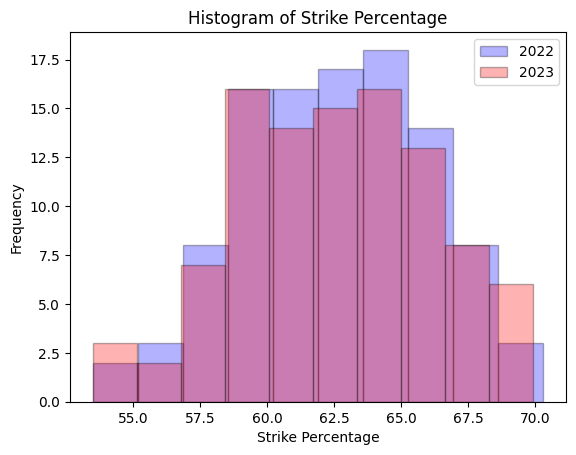

In [ ]:
plt.hist(FullAdvanced_2022['f_strike_percent'], alpha=0.3, label='2022', color='blue', edgecolor='black')
plt.hist(FullAdvanced_2023['f_strike_percent'], alpha=0.3, label='2023', color='red', edgecolor='black')

plt.title('Histogram of Strike Percentage')
plt.xlabel('Strike Percentage')
plt.ylabel('Frequency')


plt.legend()
plt.show()

In [ ]:
FullAdvanced.columns

Index(['last_name, first_name', 'player_id', 'year', 'p_formatted_ip', 'pa',
       'ab', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout',
       'walk', 'k_percent', 'bb_percent', 'batting_avg', 'slg_percent',
       'on_base_percent', 'on_base_plus_slg', 'babip', 'p_earned_run', 'p_run',
       'p_win', 'p_loss', 'p_era', 'p_opp_batting_avg', 'p_total_stolen_base',
       'p_rbi', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'exit_velocity_avg',
       'launch_angle_avg', 'sweet_spot_percent', 'barrel_batted_rate',
       'hard_hit_percent', 'avg_best_speed', 'avg_hyper_speed',
       'z_swing_percent', 'whiff_percent', 'swing_percent', 'batted_ball',
       'f_strike_percent', 'ff_avg_speed', 'sl_avg_speed', 'ch_avg_speed',
       'cu_avg_speed', 'si_avg_speed', 'fc_avg_speed', 'fs_avg_speed',
       'kn_avg_speed', 'st_avg_speed', 'sv_avg_speed', 'fo_avg_speed',
       'sc_avg_speed', 'fastball_avg_speed', 'breaking_avg_speed',
       'offspeed_avg_speed'],
      dtype='obj

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score



In [ ]:
more_stats = pd.read_csv('jeffbagwell_war_historical.csv',encoding='ISO-8859-1')
more_stats

,player_name,age,key_bbref,year_ID,team_ID,stint_ID,lg_ID,is_P,franch_ID,sched,g_bat,pa,bat162,bsr162,fld162,pos162,def162,rep162,bwar162,BB_plus,K_plus,AVG_plus,OBP_plus,SLG_plus,wRC_plus,ISO_plus,BABIP_plus,LD_plus,GB_plus,FB_plus,Pull_plus,Cent_plus,Oppo_plus,g_pitch,starts,innings,relief_pct,avg_LI,br_pwar162,fg_pwar162,ra9_pwar162,pwar162,K9_plus,BB9_plus,KBB_plus,HR9_plus,Kpct_plus,BBpct_plus,oppAVG_plus,WHIP_plus,oppBABIP_plus,LOB_plus,ERA_minus,FIP_minus,xFIP_minus,oppLD_plus,oppGB_plus,oppFB_plus,pct_PT,WAR162,gms_P,gms_C,gms_1B,gms_2B,gms_3B,gms_SS,gms_LF,gms_CF,gms_RF,gms_OF,gms_DH,gms_PH,gms_PR,prev_tm,arrived,departed,next_tm,salary
0,David Aardsma,22.0,aardsda01,2004,SFG,1,NL,Y,SFG,162,11,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,0.0,10.666667,1.000000,1.065900,-0.15,-0.3,-0.2,-0.216667,63.0,249.0,25.0,76.0,47.0,189.0,158.0,203.0,152.0,109.0,159.0,159.0,172.0,146.0,82.0,97.0,0.312389,-0.216667,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,---,2004,2004,CHC,300000.0
1,David Aardsma,24.0,aardsda01,2006,CHC,1,NL,Y,CHC,162,43,3,-0.900000,0.000000,0.000000,0.435000,0.435000,0.050000,-0.020000,0.0,0.0,0.0,0.0,0.0,-100.0,0.0,0.0,0.0,232.0,0.0,82.0,98.0,133.0,45.0,0.0,53.000000,1.000000,0.757100,0.61,-0.2,0.5,0.303333,124.0,140.0,88.0,137.0,127.0,144.0,80.0,93.0,79.0,110.0,87.0,111.0,102.0,98.0,85.0,120.0,1.579908,0.283333,45.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SFG,2006,2006,CHW,NaN
2,David Aardsma,25.0,aardsda01,2007,CHW,1,AL,Y,CHW,162,2,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,0.0,32.333333,1.000000,1.424000,-0.40,0.2,-0.6,-0.266667,151.0,143.0,106.0,111.0,140.0,133.0,111.0,123.0,125.0,91.0,138.0,92.0,95.0,114.0,84.0,112.0,0.937971,-0.266667,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CHC,2007,2007,BOS,387500.0
3,David Aardsma,26.0,aardsda01,2008,BOS,1,AL,Y,BOS,162,5,1,-0.295000,0.000000,0.000000,0.120000,0.120000,0.000000,-0.010000,0.0,594.0,0.0,0.0,0.0,-100.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,0.0,48.666667,1.000000,0.793600,-0.31,-0.1,-0.4,-0.270000,136.0,195.0,70.0,74.0,126.0,180.0,100.0,124.0,112.0,96.0,123.0,110.0,115.0,92.0,101.0,103.0,1.393461,-0.280000,47.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CHW,2008,2008,SEA,403250.0
4,David Aardsma,27.0,aardsda01,2009,SEA,1,AL,Y,SEA,162,3,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,0.0,71.333333,1.000000,1.886100,1.69,2.0,2.5,2.063333,147.0,127.0,116.0,45.0,154.0,132.0,71.0,83.0,85.0,109.0,59.0,70.0,92.0,111.0,59.0,139.0,2.097559,2.063333,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BOS,2009,2010,NYY,419000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,Dutch Zwilling,26.0,zwilldu01,1915,CHI,1,FL,N,CHH,155,150,636,29.672129,2.027613,4.180645,-3.997742,0.182903,14.078323,5.089935,129.0,123.0,109.0,111.0,126.0,140.0,173.0,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.00,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.713593,5.089935,0.0,0.0,3.0,0.0,0.0,0.0,0.0,148.0,0.0,148.0,0.0,1.0,0.0,CHW,1914,1915,CHC,NaN
112646,Dutch Zwilling,27.0,zwilldu01,1916,CHC,1,NL,N,CHC,156,35,59,-5.571346,-0.015577,-1.038462,-0.332308,-1.370769,1.879615,-0.659423,99.0,110.0,45.0,56.0,56.0,10.0,89.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.00,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.657555,-0.659423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,9.0,0.0,23.0,1.0,CHH,1916,1916,---,3250.0
112647,Tony Zych,24.0,zychto01,2015,SEA,1,AL,Y,SEA,

In [ ]:
more_stats22 = more_stats[more_stats['year_ID']==2022]
more_stats22 = more_stats22[more_stats22['is_P']=='Y']

more_stats21 = more_stats[more_stats['year_ID']==2021]
more_stats21 = more_stats21[more_stats21['is_P']=='Y']

more_stats23 = pd.read_csv('jeffbagwell_war_historical_2023.csv',encoding='ISO-8859-1')
more_stats23 = more_stats23[more_stats23['is_P']=='Y']
more_stats23 = more_stats23[more_stats23['year_ID']==2023]


In [ ]:
war_data_2021 = more_stats21.groupby('player_name')['br_pwar162'].sum().reset_index()
war_data_2021.rename(columns={'br_pwar162': 'total_war_2021'}, inplace=True)

war_data_2022 = more_stats22.groupby('player_name')['br_pwar162'].sum().reset_index()
war_data_2022.rename(columns={'br_pwar162': 'total_war_2022'}, inplace=True)

war_data_2023 = more_stats23.groupby('player_name')['br_pwar162'].sum().reset_index()
war_data_2023.rename(columns={'br_pwar162': 'total_war_2023'}, inplace=True)

In [ ]:
FullAdvanced_2021[['last_name', 'first_name']] = FullAdvanced_2021['last_name, first_name'].str.split(', ', expand=True)
FullAdvanced_2021['player_name'] = FullAdvanced_2021['first_name'] + ' ' + FullAdvanced_2021['last_name']
FullAdvanced_2021.drop(['first_name', 'last_name'], axis=1, inplace=True)

FullAdvanced_2022[['last_name', 'first_name']] = FullAdvanced_2022['last_name, first_name'].str.split(', ', expand=True)
FullAdvanced_2022['player_name'] = FullAdvanced_2022['first_name'] + ' ' + FullAdvanced_2022['last_name']
FullAdvanced_2022.drop(['first_name', 'last_name'], axis=1, inplace=True)

FullAdvanced_2023[['last_name', 'first_name']] = FullAdvanced_2023['last_name, first_name'].str.split(', ', expand=True)
FullAdvanced_2023['player_name'] = FullAdvanced_2023['first_name'] + ' ' + FullAdvanced_2023['last_name']
FullAdvanced_2023.drop(['first_name', 'last_name'], axis=1, inplace=True)

<ipython-input-18-2b1000efdd1c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FullAdvanced_2021[['last_name', 'first_name']] = FullAdvanced_2021['last_name, first_name'].str.split(', ', expand=True)
<ipython-input-18-2b1000efdd1c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FullAdvanced_2021[['last_name', 'first_name']] = FullAdvanced_2021['last_name, first_name'].str.split(', ', expand=True)
<ipython-input-18-2b1000efdd1c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [ ]:
combined_data_2021 = pd.merge(FullAdvanced_2021, war_data_2021, on='player_name', how='inner')
combined_data_2021

combined_data_2022 = pd.merge(FullAdvanced_2022, war_data_2022, on='player_name', how='inner')
combined_data_2022

combined_data_2023 = pd.merge(FullAdvanced_2023, war_data_2023, on='player_name', how='inner')
combined_data_2023

combined_data_2021.shape, combined_data_2022.shape, combined_data_2023.shape

((92, 62), (93, 62), (99, 62))

In [ ]:
combined_data_2021

,"last_name, first_name",player_id,year,p_formatted_ip,pa,ab,hit,single,double,triple,home_run,strikeout,walk,k_percent,bb_percent,batting_avg,slg_percent,on_base_percent,on_base_plus_slg,babip,p_earned_run,p_run,p_win,p_loss,p_era,p_opp_batting_avg,p_total_stolen_base,p_rbi,xba,xslg,woba,xwoba,xobp,exit_velocity_avg,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,avg_hyper_speed,z_swing_percent,whiff_percent,swing_percent,batted_ball,f_strike_percent,ff_avg_speed,sl_avg_speed,ch_avg_speed,cu_avg_speed,si_avg_speed,fc_avg_speed,fs_avg_speed,kn_avg_speed,st_avg_speed,sv_avg_speed,fo_avg_speed,sc_avg_speed,fastball_avg_speed,breaking_avg_speed,offspeed_avg_speed,player_name,total_war_2021
0,"Wainwright, Adam",425794,2021,206.1,828,765,168,111,34,2,21,174,50,21.0,6.0,0.220,0.352,0.275,0.627,0.257,70,72,17,7,3.05,NaN,3,66,0.251,0.388,0.273,0.302,0.304,88.2,10.0,34.3,6.2,35.6,77.656330,93.426714,60.7,19.7,43.8,595,64.4,89.0,NaN,82.7,73.4,89.1,84.9,NaN,NaN,NaN,NaN,NaN,NaN,87.5,73.4,82.7,Adam Wainwright,3.610000
1,"Greinke, Zack",425844,2021,171.0,697,652,164,105,29,0,30,120,36,17.2,5.2,0.252,0.434,0.291,0.725,0.264,79,82,11,6,4.16,NaN,7,78,0.266,0.430,0.309,0.319,0.306,88.3,10.6,35.3,6.5,35.4,77.616197,93.635625,66.4,21.8,46.0,539,66.0,88.9,83.6,86.4,71.1,89.5,85.2,NaN,NaN,NaN,NaN,NaN,NaN,89.0,77.0,86.4,Zack Greinke,1.190000
2,"Hill, Rich",448179,2021,158.2,661,582,137,83,32,1,21,150,55,22.7,8.3,0.235,0.402,0.316,0.718,0.279,68,70,7,8,3.86,NaN,9,65,0.240,0.414,0.313,0.323,0.323,88.3,18.0,37.0,8.9,34.8,77.366844,93.717794,64.0,23.1,46.1,440,62.5,88.1,76.5,80.9,71.7,84.8,83.7,NaN,NaN,69.1,NaN,NaN,NaN,87.7,71.4,80.9,Rich Hill,1.450000
3,"Morton, Charlie",450203,2021,185.2,756,669,136,100,17,3,16,216,58,28.6,7.7,0.203,0.309,0.281,0.590,0.271,69,77,14,6,3.34,NaN,7,70,0.217,0.332,0.264,0.282,0.295,88.1,7.7,29.9,4.9,32.5,77.626260,93.368970,64.5,28.9,46.0,465,58.2,95.5,NaN,86.4,80.6,94.6,87.5,NaN,NaN,NaN,NaN,NaN,NaN,94.1,80.6,86.4,Charlie Morton,4.105342
4,"Lester, Jon",452657,2021,141.1,627,558,159,101,33,0,25,91,55,14.5,8.8,0.285,0.478,0.349,0.827,0.300,74,84,7,6,4.71,NaN,11,76,0.274,0.453,0.352,0.343,0.342,88.3,10.4,33.5,7.7,37.2,76.810551,93.976800,70.5,20.0,46.4,478,56.9,88.7,NaN,81.3,72.6,87.6,86.4,NaN,NaN,NaN,NaN,NaN,NaN,87.6,72.6,81.3,Jon Lester,-0.550000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,"Burnes, Corbin",669203,2021,167.0,657,612,123,96,17,3,7,234,34,35.6,5.2,0.201,0.273,0.248,0.521,0.309,45,47,11,5,2.43,NaN,18,41,0.180,0.256,0.232,0.219,0.229,85.5,8.4,29.5,3.1,30.5,73.534578,92.749467,64.9,36.5,49.2,383,62.4,96.6,88.0,90.7,81.2,96.8,95.2,NaN,NaN,NaN,NaN,NaN,NaN,95.5,83.5,90.7,Corbin Burnes,5.580000
88,"Gilbert, Logan",669302,2021,119.1,503,464,112,63,30,2,17,128,28,25.4,5.6,0.241,0.425,0.291,0.716,0.295,62,63,6,5,4.68,NaN,10,56,0.242,0.427,0.305,0.310,0.294,90.1,19.2,36.4,8.8,44.6,79.708085,94.684914,75.2,27.1,50.9,341,62.2,95.3,83.4,79.9,75.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.3,81.5,79.9,Logan Gilbert,0.980000
89,"Skubal, Tarik",669373,2021,149.1,634,576,141,78,28,0,35,164,47,25.9,7.4,0.245,0.476,0.306,0.782,0.278,72,76,8,12,4.34,NaN,5,71,0.267,0.508,0.332,0.357,0.327,90.5,14.1,35.3,13.9,45.1,78.796213,95.450603,70.1,26.7,48.9,417,64.2,94.3,86.5,82.1,73.8,94.5,94.2,85.1,NaN,NaN,NaN,NaN,NaN,94.4,83.6,82.6,Tarik Skubal,1.740000
90,"Rogers, Trevor",669432,2021,133.0,550,490,107,70,31,0,6,157,46,28.5,8.4,0.218,0.318,0.291,0.609,0.307,39,46,7,8,2.64,NaN,9,40,0.223,0.343,0.270,0.284,0.296,87.7,12.5,34.9,5.0,36.7,75.956439,93.768584,68.1,30.7,49.4,341,56.9,94.5,81.8,84.8,NaN,94.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.5,81.8,84.8,Trevor Rogers,3.460000


In [ ]:
war_2021 = combined_data_2021[['player_name', 'total_war_2021']].rename(columns={'total_war_2021': 'WAR_2021'})
war_2022 = combined_data_2022[['player_name', 'total_war_2022']].rename(columns={'total_war_2022': 'WAR_2022'})
war_2023 = combined_data_2023[['player_name', 'total_war_2023']].rename(columns={'total_war_2023': 'WAR_2023'})


war_comparison = war_2021.merge(war_2022, on='player_name', how='inner').merge(war_2023, on='player_name', how='inner')
war_comparison

,player_name,WAR_2021,WAR_2022,WAR_2023
0,Zack Greinke,1.190000,2.55,0.99
1,Rich Hill,1.450000,0.86,-0.59
2,Charlie Morton,4.105342,1.61,3.14
3,Max Scherzer,5.900000,5.24,3.23
4,Lance Lynn,5.340000,0.80,-0.82
5,Kyle Gibson,3.470000,0.65,0.87
6,Yu Darvish,1.430000,4.39,0.71
7,Merrill Kelly,2.490000,3.55,3.86
8,Tyler Anderson,1.610000,4.28,0.20
9,Gerrit Cole,5.690000,2.41,7.47


In [ ]:
# Calculate WAR change between 2021-2022 and 2022-2023
war_comparison['WAR_change_2021_2022'] = war_comparison['WAR_2022'] - war_comparison['WAR_2021']
war_comparison['WAR_change_2022_2023'] = war_comparison['WAR_2023'] - war_comparison['WAR_2022']

# Define an improvement label based on WAR change for 2022-2023 (target for classification)
war_comparison['baseline_performance'] = war_comparison['WAR_change_2021_2022'].apply(
    lambda x: 'improved' if x > 0 else ('declined' if x < 0 else 'unchanged')
)

war_comparison['performance_change'] = war_comparison['WAR_change_2022_2023'].apply(
    lambda x: 'improved' if x > 0 else ('declined' if x < 0 else 'unchanged')
)


In [ ]:
# Merge with 2022 stats data for training
combined_data_2022 = combined_data_2022.merge(
    war_comparison[['player_name', 'baseline_performance']], on='player_name', how='inner'
)

# Merge with 2023 stats data for testing
combined_data_2023 = combined_data_2023.merge(
    war_comparison[['player_name', 'performance_change']], on='player_name', how='inner'
)


In [ ]:
combined_data_2022

,"last_name, first_name",player_id,year,p_formatted_ip,pa,ab,hit,single,double,triple,home_run,strikeout,walk,k_percent,bb_percent,batting_avg,slg_percent,on_base_percent,on_base_plus_slg,babip,p_earned_run,p_run,p_win,p_loss,p_era,p_opp_batting_avg,p_total_stolen_base,p_rbi,xba,xslg,woba,xwoba,xobp,exit_velocity_avg,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,avg_hyper_speed,z_swing_percent,whiff_percent,swing_percent,batted_ball,f_strike_percent,ff_avg_speed,sl_avg_speed,ch_avg_speed,cu_avg_speed,si_avg_speed,fc_avg_speed,fs_avg_speed,kn_avg_speed,st_avg_speed,sv_avg_speed,fo_avg_speed,sc_avg_speed,fastball_avg_speed,breaking_avg_speed,offspeed_avg_speed,player_name,total_war_2022,baseline_performance
0,"Greinke, Zack",425844,2022,137.0,585,549,157,113,30,0,14,73,27,12.5,4.6,0.286,0.417,0.320,0.737,0.306,56,65,4,9,3.68,NaN,6,59,0.284,0.441,0.321,0.336,0.322,88.9,12.6,34.4,6.8,39.6,78.554946,93.738299,63.9,17.3,46.2,482,64.8,89.2,81.8,86.5,72.0,89.4,85.8,NaN,NaN,NaN,NaN,NaN,NaN,88.3,74.6,86.5,Zack Greinke,2.55,improved
1,"Hill, Rich",448179,2022,124.1,526,484,125,77,27,6,15,109,37,20.7,7.0,0.258,0.432,0.316,0.748,0.305,59,67,8,7,4.27,NaN,7,59,0.240,0.411,0.325,0.313,0.300,88.2,14.9,31.6,8.2,34.0,77.422953,93.666610,64.6,22.0,47.4,376,63.3,88.5,NaN,82.8,71.8,87.3,84.2,NaN,NaN,69.2,NaN,NaN,NaN,87.4,71.2,82.8,Rich Hill,0.86,declined
2,"Morton, Charlie",450203,2022,172.0,728,640,149,93,26,2,28,205,63,28.2,8.7,0.233,0.411,0.316,0.727,0.293,83,85,9,6,4.34,NaN,10,79,0.228,0.389,0.320,0.313,0.314,89.3,13.6,38.0,9.5,42.1,78.111657,94.430490,63.6,29.2,45.6,442,58.7,94.9,NaN,87.2,81.3,94.7,88.4,NaN,NaN,NaN,NaN,NaN,NaN,93.7,81.3,87.2,Charlie Morton,1.61,declined
3,"Scherzer, Max",453286,2022,145.1,565,523,108,75,20,0,13,173,24,30.6,4.2,0.207,0.319,0.254,0.573,0.279,37,39,11,5,2.29,NaN,4,35,0.202,0.339,0.254,0.265,0.253,87.8,21.3,32.2,8.4,33.9,76.739445,93.468019,70.0,30.6,52.2,357,66.4,94.0,85.0,84.1,75.0,NaN,89.2,NaN,NaN,NaN,NaN,NaN,NaN,93.2,82.1,84.1,Max Scherzer,5.24,declined
4,"Lynn, Lance",458681,2022,121.2,512,481,119,80,20,0,19,124,19,24.2,3.7,0.247,0.407,0.289,0.696,0.294,54,65,8,7,3.99,NaN,1,55,0.242,0.387,0.304,0.296,0.286,88.4,14.2,34.3,6.7,38.7,77.366722,93.833570,74.9,28.5,52.3,359,65.4,92.9,86.0,85.8,82.0,91.4,88.8,NaN,NaN,NaN,NaN,NaN,NaN,91.4,82.9,85.8,Lance Lynn,0.80,declined
5,"Gibson, Kyle",502043,2022,167.2,718,656,176,117,33,2,24,144,48,20.1,6.7,0.268,0.434,0.325,0.759,0.309,94,98,10,8,5.05,NaN,3,88,0.262,0.420,0.331,0.326,0.320,88.6,10.6,34.8,7.5,37.5,77.435542,93.992252,68.4,25.1,48.5,517,58.9,92.0,83.4,84.7,79.1,91.7,89.4,NaN,NaN,82.9,NaN,NaN,NaN,90.9,82.3,84.7,Kyle Gibson,0.65,declined
6,"Darvish, Yu",506433,2022,194.2,771,715,148,103,23,0,22,197,37,25.6,4.8,0.207,0.331,0.256,0.587,0.251,67,67,16,8,3.10,NaN,14,59,0.226,0.388,0.259,0.291,0.275,88.5,17.0,31.2,8.8,37.1,77.848460,93.614824,65.3,25.1,49.7,525,64.2,95.0,86.0,NaN,76.1,94.7,90.7,89.2,NaN,82.7,NaN,NaN,NaN,94.4,83.7,89.2,Yu Darvish,4.39,improved
7,"Kelly, Merrill",518876,2022,200.1,804,739,167,104,40,2,21,177,61,22.0,7.6,0.226,0.371,0.286,0.657,0.269,75,77,13,8,3.37,NaN,15,69,0.230,0.383,0.289,0.296,0.291,88.5,14.0,31.2,8.3,36.5,77.983407,93.653413,67.7,23.6,48.5,564,62.4,92.6,85.0,88.6,82.2,92.5,90.8,NaN,NaN,NaN,NaN,NaN,NaN,92.1,82.2,88.6,Merrill Kelly,3.55,improved
8,"Anderson, Tyler",542881,2022,178.2,707,657,145,94,31,6,14,138,34,19.5,4.8,0.221,0.350,0.267,0.617,0.257,51,57,15,5,2.57,NaN,4,50,0.225,0.349,0.271,0.275,0.272,85.0,16.9,34.2,4.9,28.5,73.228447,92.353432,68.9,24.2,52.7,526,66.1,90.7,NaN,79.0,73.2,89.0,85.7,NaN,NaN,NaN,NaN,NaN,NaN,88.9,73.2,79.0,Tyler Anderson,4.28,improved
9,"Cole, Gerrit",543037,2022,200.2,793,738,154,88,31,2,33,257,50,32.4,6.3,0.209,0.390,0.260,0.650,0.269,78,81,13,8,3.50,NaN,11,78,0.214,0.383,0.283,0.284,0.266,89.4,12.6,32.5,9.5,40.2,78.808854,94.227606,65.8,33.9,48.2,483,61.5,97.8,88.7,89.7,83.0,NaN,92.0,NaN,NaN,NaN,NaN,NaN,NaN,97.1,86.8,89.7,Gerrit Cole,2.41,declined


In [ ]:
combined_data_2022.columns

Index(['last_name, first_name', 'player_id', 'year', 'p_formatted_ip', 'pa',
       'ab', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout',
       'walk', 'k_percent', 'bb_percent', 'batting_avg', 'slg_percent',
       'on_base_percent', 'on_base_plus_slg', 'babip', 'p_earned_run', 'p_run',
       'p_win', 'p_loss', 'p_era', 'p_opp_batting_avg', 'p_total_stolen_base',
       'p_rbi', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'exit_velocity_avg',
       'launch_angle_avg', 'sweet_spot_percent', 'barrel_batted_rate',
       'hard_hit_percent', 'avg_best_speed', 'avg_hyper_speed',
       'z_swing_percent', 'whiff_percent', 'swing_percent', 'batted_ball',
       'f_strike_percent', 'ff_avg_speed', 'sl_avg_speed', 'ch_avg_speed',
       'cu_avg_speed', 'si_avg_speed', 'fc_avg_speed', 'fs_avg_speed',
       'kn_avg_speed', 'st_avg_speed', 'sv_avg_speed', 'fo_avg_speed',
       'sc_avg_speed', 'fastball_avg_speed', 'breaking_avg_speed',
       'offspeed_avg_speed', 'player_name', 't

In [ ]:
FullAdvanced_2021['k_percent']

,k_percent
0,21.0
1,17.2
2,22.7
3,28.6
4,14.5
...,...
94,35.6
95,25.4
96,25.9
97,28.5


In [ ]:
# Example of defining performance change thresholds
FullAdvanced_2022['k_percent_diff'] = FullAdvanced_2022['k_percent'] - FullAdvanced_2021['k_percent']
FullAdvanced_2022['bb_percent_diff'] = FullAdvanced_2022['bb_percent'] - FullAdvanced_2021['bb_percent']
FullAdvanced_2022['fastball_speed_diff'] = FullAdvanced_2022['fastball_avg_speed'] - FullAdvanced_2021['fastball_avg_speed']
FullAdvanced_2022['opp_ba_diff'] = FullAdvanced_2022['p_opp_batting_avg'] - FullAdvanced_2021['p_opp_batting_avg']


# Define improvement, no change, or decline based on thresholds
# Define improvement, no change, or decline based on adjusted thresholds
FullAdvanced_2022['performance_change'] = "No Change"  # Default to no change

# Improvement criteria
FullAdvanced_2022.loc[(FullAdvanced_2022['k_percent_diff'] > 0) & (FullAdvanced_2022['opp_ba_diff'] < -0.010), 'performance_change'] = "Improved"

# Decline criteria
FullAdvanced_2022.loc[(FullAdvanced_2022['k_percent_diff'] < 0) & (FullAdvanced_2022['opp_ba_diff'] > 0.010), 'performance_change'] = "Declined"

FullAdvanced_2022

<ipython-input-27-471a2af297f1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FullAdvanced_2022['k_percent_diff'] = FullAdvanced_2022['k_percent'] - FullAdvanced_2021['k_percent']
<ipython-input-27-471a2af297f1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FullAdvanced_2022['bb_percent_diff'] = FullAdvanced_2022['bb_percent'] - FullAdvanced_2021['bb_percent']
<ipython-input-27-471a2af297f1>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,"last_name, first_name",player_id,year,p_formatted_ip,pa,ab,hit,single,double,triple,home_run,strikeout,walk,k_percent,bb_percent,batting_avg,slg_percent,on_base_percent,on_base_plus_slg,babip,p_earned_run,p_run,p_win,p_loss,p_era,p_opp_batting_avg,p_total_stolen_base,p_rbi,xba,xslg,woba,xwoba,xobp,exit_velocity_avg,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,avg_hyper_speed,z_swing_percent,whiff_percent,swing_percent,batted_ball,f_strike_percent,ff_avg_speed,sl_avg_speed,ch_avg_speed,cu_avg_speed,si_avg_speed,fc_avg_speed,fs_avg_speed,kn_avg_speed,st_avg_speed,sv_avg_speed,fo_avg_speed,sc_avg_speed,fastball_avg_speed,breaking_avg_speed,offspeed_avg_speed,player_name,k_percent_diff,bb_percent_diff,fastball_speed_diff,opp_ba_diff,performance_change
99,"Wainwright, Adam",425794,2022,191.2,803,736,192,138,35,3,16,143,54,17.8,6.7,0.261,0.382,0.315,0.697,0.302,79,80,11,12,3.71,NaN,8,72,0.270,0.418,0.306,0.328,0.326,87.8,11.0,37.4,6.5,36.6,76.636928,93.594970,61.6,16.9,43.5,599,62.6,88.0,75.3,82.2,72.8,88.6,84.3,NaN,NaN,NaN,NaN,NaN,NaN,86.8,72.8,82.2,Adam Wainwright,NaN,NaN,NaN,NaN,No Change
100,"Greinke, Zack",425844,2022,137.0,585,549,157,113,30,0,14,73,27,12.5,4.6,0.286,0.417,0.320,0.737,0.306,56,65,4,9,3.68,NaN,6,59,0.284,0.441,0.321,0.336,0.322,88.9,12.6,34.4,6.8,39.6,78.554946,93.738299,63.9,17.3,46.2,482,64.8,89.2,81.8,86.5,72.0,89.4,85.8,NaN,NaN,NaN,NaN,NaN,NaN,88.3,74.6,86.5,Zack Greinke,NaN,NaN,NaN,NaN,No Change
101,"Verlander, Justin",434378,2022,175.0,666,625,116,88,15,1,12,185,29,27.8,4.4,0.186,0.270,0.227,0.497,0.240,34,43,18,4,1.75,NaN,10,40,0.207,0.331,0.222,0.255,0.248,87.8,16.9,32.5,6.3,34.8,77.135794,93.330588,74.2,24.2,53.7,446,62.0,95.0,87.4,86.2,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.0,84.1,86.2,Justin Verlander,NaN,NaN,NaN,NaN,No Change
102,"Kluber, Corey",446372,2022,164.0,689,650,178,123,32,3,20,139,21,20.2,3.0,0.274,0.425,0.304,0.729,0.318,79,82,10,10,4.34,NaN,5,80,0.261,0.416,0.316,0.310,0.294,87.1,18.5,35.8,6.9,34.7,75.470981,93.389889,66.2,23.9,51.2,519,68.4,88.9,NaN,82.9,80.7,88.9,86.3,NaN,NaN,NaN,NaN,NaN,NaN,87.5,80.7,82.9,Corey Kluber,NaN,NaN,NaN,NaN,No Change
103,"Hill, Rich",448179,2022,124.1,526,484,125,77,27,6,15,109,37,20.7,7.0,0.258,0.432,0.316,0.748,0.305,59,67,8,7,4.27,NaN,7,59,0.240,0.411,0.325,0.313,0.300,88.2,14.9,31.6,8.2,34.0,77.422953,93.666610,64.6,22.0,47.4,376,63.3,88.5,NaN,82.8,71.8,87.3,84.2,NaN,NaN,69.2,NaN,NaN,NaN,87.4,71.2,82.8,Rich Hill,NaN,NaN,NaN,NaN,No Change
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,"Detmers, Reid",672282,2022,129.0,539,477,110,68,27,2,13,122,46,22.6,8.5,0.231,0.377,0.305,0.682,0.278,54,56,7,6,3.77,NaN,13,49,0.243,0.388,0.300,0.312,0.318,89.3,16.7,39.9,8.0,38.6,79.426417,93.829833,68.0,25.3,48.3,363,60.1,93.2,86.3,84.2,73.1,93.7,NaN,NaN,NaN,80.2,NaN,NaN,NaN,93.2,80.6,84.2,Reid Detmers,NaN,NaN,NaN,NaN,No Change
200,"Strider, Spencer",675911,2022,131.2,528,478,86,61,17,1,7,202,45,38.3,8.5,0.180,0.264,0.254,0.518,0.292,39,42,11,5,2.67,NaN,4,32,0.179,0.279,0.235,0.242,0.254,88.0,14.1,32.7,6.1,36.0,77.317559,93.436230,68.3,34.9,50.0,278,60.2,98.2,86.3,88.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.2,86.3,88.9,Spencer Strider,NaN,NaN,NaN,NaN,No Change
201,"Garcia, Luis",677651,2022,157.1,643,589,131,77,27,4,23,157,47,24.4,7.3,0.222,0.399,0.279,0.678,0.261,65,70,15,8,3.72,NaN,5,62,0.227,0.383,0.295,0.294,0.285,88.4,17.1,35.4,7.8,36.3,77.928198,93.466990,69.5,29.1,48.9,438,58.2,94.0,79.5,84.8,77.1,90.6,85.3,NaN,NaN,NaN,NaN,NaN,NaN,90.4,78.2,84.8,Luis Garcia,NaN,NaN,NaN,NaN,No Change
202,"Gray, Josiah",680686,2022,148.2,649,569,136,74,20,4,38,154,66,23.7,10.2,0.239,0.489,0.324,0.813,0.257,83,84,7,10,5.02,NaN,11,80,0.218,0.419,0.350,0.319,0.308,87.4,19.7,33.6,10.7,36.9,75.597201,93.715460,64.8,26.9,44

In [ ]:
# Define X (features) and Y (target)
feature_columns = [
    'p_earned_run', 'p_era', 'p_opp_batting_avg', 'p_total_stolen_base', 'p_rbi',
     'exit_velocity_avg', 'launch_angle_avg',
    'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent',
    'fastball_avg_speed', 'breaking_avg_speed', 'offspeed_avg_speed',
    'k_percent', 'bb_percent', 'whiff_percent', 'swing_percent', 'z_swing_percent', 'f_strike_percent'
]

X = combined_data_2022[feature_columns]
Y = combined_data_2022['baseline_performance']

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Split into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

# Predict on test data
Y_pred = rf_model.predict(X_test)

# Evaluate the model
print(classification_report(Y_test, Y_pred))
print(accuracy_score(Y_test, Y_pred))

              precision    recall  f1-score   support

    declined       0.38      0.75      0.50         4
    improved       0.67      0.29      0.40         7

    accuracy                           0.45        11
   macro avg       0.52      0.52      0.45        11
weighted avg       0.56      0.45      0.44        11

0.45454545454545453


Top 10 Features by Importance:
               Feature  Importance
0       p_formatted_ip    0.078009
40         batted_ball    0.070433
2                   ab    0.058626
1                   pa    0.052269
26                xslg    0.045695
38       whiff_percent    0.042441
16               babip    0.038701
41    f_strike_percent    0.037814
33  barrel_batted_rate    0.035591
12         batting_avg    0.027792


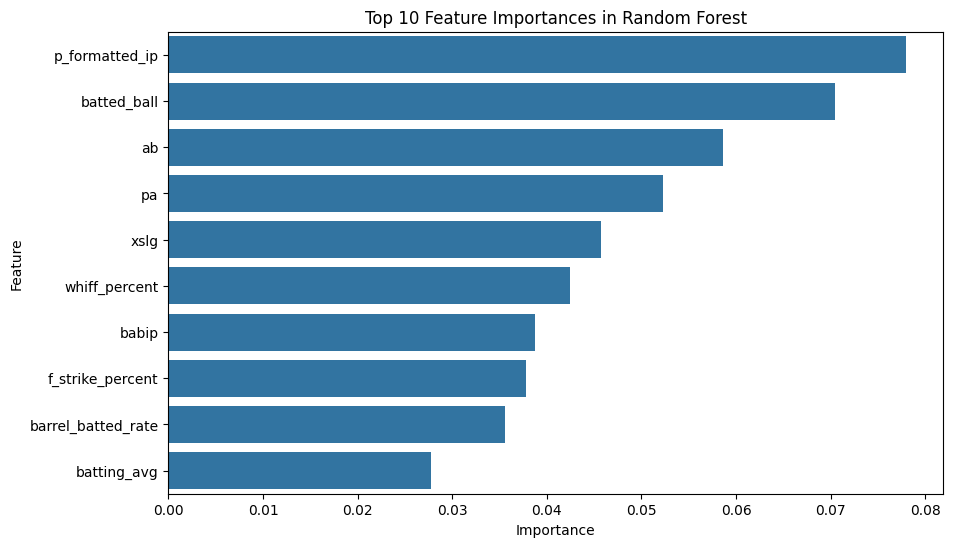

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_columns = ['p_formatted_ip', 'pa',
       'ab', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout',
       'walk', 'k_percent', 'bb_percent', 'batting_avg', 'slg_percent',
       'on_base_percent', 'on_base_plus_slg', 'babip', 'p_earned_run', 'p_run',
       'p_win', 'p_loss', 'p_era', 'p_opp_batting_avg', 'p_total_stolen_base',
       'p_rbi', 'xba', 'xslg', 'woba', 'xwoba', 'xobp', 'exit_velocity_avg',
       'launch_angle_avg', 'sweet_spot_percent', 'barrel_batted_rate',
       'hard_hit_percent', 'avg_best_speed', 'avg_hyper_speed',
       'z_swing_percent', 'whiff_percent', 'swing_percent', 'batted_ball',
       'f_strike_percent', 'ff_avg_speed', 'sl_avg_speed', 'ch_avg_speed',
       'cu_avg_speed', 'si_avg_speed', 'fc_avg_speed', 'fs_avg_speed',
       'kn_avg_speed', 'st_avg_speed', 'sv_avg_speed', 'fo_avg_speed',
       'sc_avg_speed', 'fastball_avg_speed', 'breaking_avg_speed',
       'offspeed_avg_speed']

X = combined_data_2022[feature_columns]
Y = combined_data_2022['baseline_performance']

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Split into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check and generate the feature importances DataFrame
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select the top 10 features
top_10_features = importance_df.head(10)

# Print the top 10 features
print("Top 10 Features by Importance:")
print(top_10_features)

# Plot the top 10 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, color = "#765145")
plt.title("Top 10 Feature Importances in Random Forest")
plt.show()


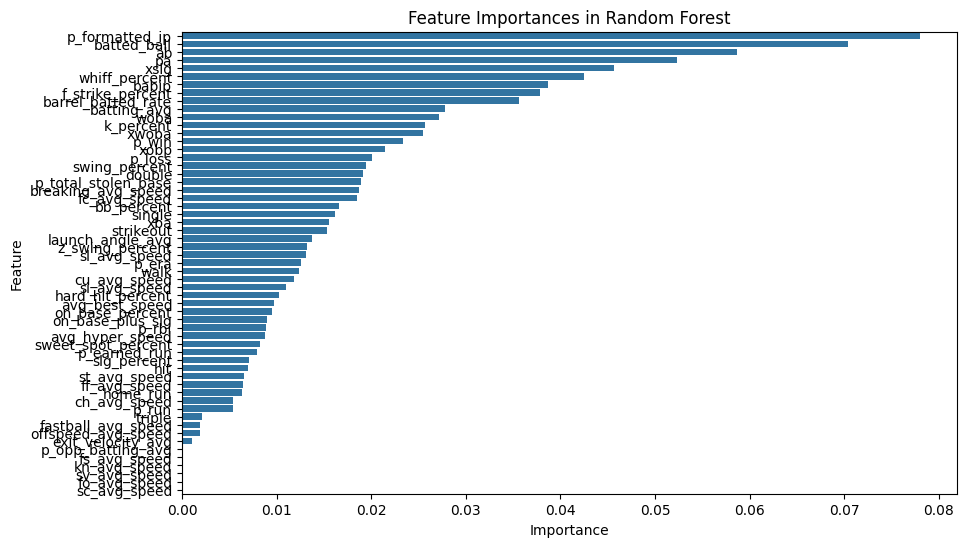

In [ ]:
import seaborn as sns
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importances in Random Forest")
plt.show()

              precision    recall  f1-score   support

    declined       0.38      0.75      0.50         4
    improved       0.67      0.29      0.40         7

    accuracy                           0.45        11
   macro avg       0.52      0.52      0.45        11
weighted avg       0.56      0.45      0.44        11

0.45454545454545453


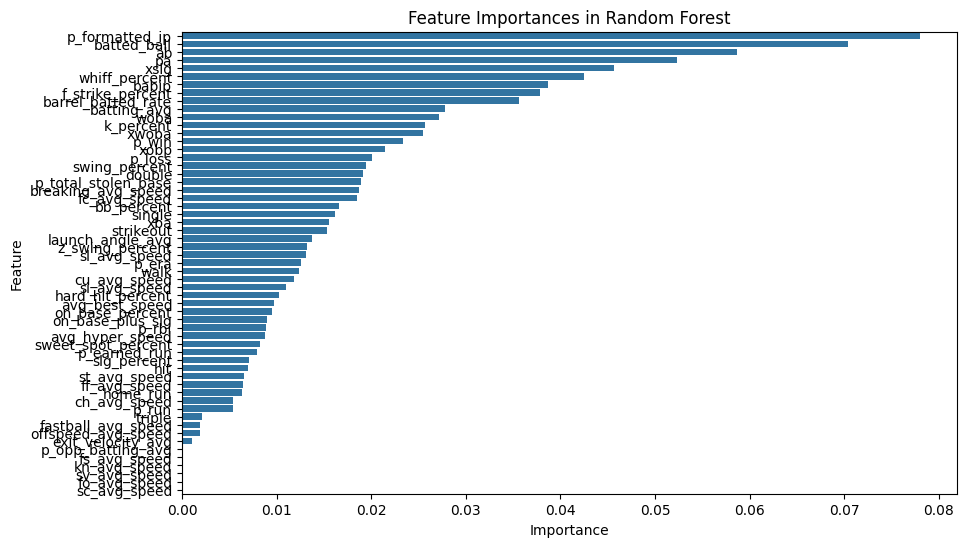

In [ ]:
feature_columns = [
    'p_era', 'p_total_stolen_base',
     'launch_angle_avg',
    'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent',
     'offspeed_avg_speed',
    'whiff_percent', 'z_swing_percent', 'f_strike_percent'
]

X = combined_data_2022[feature_columns]
Y = combined_data_2022['baseline_performance']

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Split into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

# Predict on test data
Y_pred = rf_model.predict(X_test)

# Evaluate the model
print(classification_report(Y_test, Y_pred))
print(accuracy_score(Y_test, Y_pred))

# Plot feature importances
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importances in Random Forest")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for n_estimators
param_grid = {
    'n_estimators': [100, 200, 500, 1000]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

print("Best n_estimators:", grid_search.best_params_['n_estimators'])


Best n_estimators: 100


In [ ]:
param_grid = {
    'max_depth': [5, 10, 20, 30, None]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

print("Best max_depth:", grid_search.best_params_['max_depth'])


Best max_depth: 10


In [ ]:
param_grid = {
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

print("Best min_samples_leaf:", grid_search.best_params_['min_samples_leaf'])


Best min_samples_leaf: 1


In [ ]:
param_grid = {
    'min_samples_split': [2, 5, 10, 15]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

print("Best min_samples_split:", grid_search.best_params_['min_samples_split'])


Best min_samples_split: 2


In [ ]:
combined_data_2022

,"last_name, first_name",player_id,year,p_formatted_ip,pa,ab,hit,single,double,triple,home_run,strikeout,walk,k_percent,bb_percent,batting_avg,slg_percent,on_base_percent,on_base_plus_slg,babip,p_earned_run,p_run,p_win,p_loss,p_era,p_opp_batting_avg,p_total_stolen_base,p_rbi,xba,xslg,woba,xwoba,xobp,exit_velocity_avg,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,avg_hyper_speed,z_swing_percent,whiff_percent,swing_percent,batted_ball,f_strike_percent,ff_avg_speed,sl_avg_speed,ch_avg_speed,cu_avg_speed,si_avg_speed,fc_avg_speed,fs_avg_speed,kn_avg_speed,st_avg_speed,sv_avg_speed,fo_avg_speed,sc_avg_speed,fastball_avg_speed,breaking_avg_speed,offspeed_avg_speed,player_name,total_war_2022,baseline_performance
0,"Greinke, Zack",425844,2022,137.0,585,549,157,113,30,0,14,73,27,12.5,4.6,0.286,0.417,0.320,0.737,0.306,56,65,4,9,3.68,NaN,6,59,0.284,0.441,0.321,0.336,0.322,88.9,12.6,34.4,6.8,39.6,78.554946,93.738299,63.9,17.3,46.2,482,64.8,89.2,81.8,86.5,72.0,89.4,85.8,NaN,NaN,NaN,NaN,NaN,NaN,88.3,74.6,86.5,Zack Greinke,2.55,improved
1,"Hill, Rich",448179,2022,124.1,526,484,125,77,27,6,15,109,37,20.7,7.0,0.258,0.432,0.316,0.748,0.305,59,67,8,7,4.27,NaN,7,59,0.240,0.411,0.325,0.313,0.300,88.2,14.9,31.6,8.2,34.0,77.422953,93.666610,64.6,22.0,47.4,376,63.3,88.5,NaN,82.8,71.8,87.3,84.2,NaN,NaN,69.2,NaN,NaN,NaN,87.4,71.2,82.8,Rich Hill,0.86,declined
2,"Morton, Charlie",450203,2022,172.0,728,640,149,93,26,2,28,205,63,28.2,8.7,0.233,0.411,0.316,0.727,0.293,83,85,9,6,4.34,NaN,10,79,0.228,0.389,0.320,0.313,0.314,89.3,13.6,38.0,9.5,42.1,78.111657,94.430490,63.6,29.2,45.6,442,58.7,94.9,NaN,87.2,81.3,94.7,88.4,NaN,NaN,NaN,NaN,NaN,NaN,93.7,81.3,87.2,Charlie Morton,1.61,declined
3,"Scherzer, Max",453286,2022,145.1,565,523,108,75,20,0,13,173,24,30.6,4.2,0.207,0.319,0.254,0.573,0.279,37,39,11,5,2.29,NaN,4,35,0.202,0.339,0.254,0.265,0.253,87.8,21.3,32.2,8.4,33.9,76.739445,93.468019,70.0,30.6,52.2,357,66.4,94.0,85.0,84.1,75.0,NaN,89.2,NaN,NaN,NaN,NaN,NaN,NaN,93.2,82.1,84.1,Max Scherzer,5.24,declined
4,"Lynn, Lance",458681,2022,121.2,512,481,119,80,20,0,19,124,19,24.2,3.7,0.247,0.407,0.289,0.696,0.294,54,65,8,7,3.99,NaN,1,55,0.242,0.387,0.304,0.296,0.286,88.4,14.2,34.3,6.7,38.7,77.366722,93.833570,74.9,28.5,52.3,359,65.4,92.9,86.0,85.8,82.0,91.4,88.8,NaN,NaN,NaN,NaN,NaN,NaN,91.4,82.9,85.8,Lance Lynn,0.80,declined
5,"Gibson, Kyle",502043,2022,167.2,718,656,176,117,33,2,24,144,48,20.1,6.7,0.268,0.434,0.325,0.759,0.309,94,98,10,8,5.05,NaN,3,88,0.262,0.420,0.331,0.326,0.320,88.6,10.6,34.8,7.5,37.5,77.435542,93.992252,68.4,25.1,48.5,517,58.9,92.0,83.4,84.7,79.1,91.7,89.4,NaN,NaN,82.9,NaN,NaN,NaN,90.9,82.3,84.7,Kyle Gibson,0.65,declined
6,"Darvish, Yu",506433,2022,194.2,771,715,148,103,23,0,22,197,37,25.6,4.8,0.207,0.331,0.256,0.587,0.251,67,67,16,8,3.10,NaN,14,59,0.226,0.388,0.259,0.291,0.275,88.5,17.0,31.2,8.8,37.1,77.848460,93.614824,65.3,25.1,49.7,525,64.2,95.0,86.0,NaN,76.1,94.7,90.7,89.2,NaN,82.7,NaN,NaN,NaN,94.4,83.7,89.2,Yu Darvish,4.39,improved
7,"Kelly, Merrill",518876,2022,200.1,804,739,167,104,40,2,21,177,61,22.0,7.6,0.226,0.371,0.286,0.657,0.269,75,77,13,8,3.37,NaN,15,69,0.230,0.383,0.289,0.296,0.291,88.5,14.0,31.2,8.3,36.5,77.983407,93.653413,67.7,23.6,48.5,564,62.4,92.6,85.0,88.6,82.2,92.5,90.8,NaN,NaN,NaN,NaN,NaN,NaN,92.1,82.2,88.6,Merrill Kelly,3.55,improved
8,"Anderson, Tyler",542881,2022,178.2,707,657,145,94,31,6,14,138,34,19.5,4.8,0.221,0.350,0.267,0.617,0.257,51,57,15,5,2.57,NaN,4,50,0.225,0.349,0.271,0.275,0.272,85.0,16.9,34.2,4.9,28.5,73.228447,92.353432,68.9,24.2,52.7,526,66.1,90.7,NaN,79.0,73.2,89.0,85.7,NaN,NaN,NaN,NaN,NaN,NaN,88.9,73.2,79.0,Tyler Anderson,4.28,improved
9,"Cole, Gerrit",543037,2022,200.2,793,738,154,88,31,2,33,257,50,32.4,6.3,0.209,0.390,0.260,0.650,0.269,78,81,13,8,3.50,NaN,11,78,0.214,0.383,0.283,0.284,0.266,89.4,12.6,32.5,9.5,40.2,78.808854,94.227606,65.8,33.9,48.2,483,61.5,97.8,88.7,89.7,83.0,NaN,92.0,NaN,NaN,NaN,NaN,NaN,NaN,97.1,86.8,89.7,Gerrit Cole,2.41,declined


In [ ]:
feature_columns = [
    'p_era', 'p_total_stolen_base',
     'launch_angle_avg',
    'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent',
     'offspeed_avg_speed',
    'whiff_percent', 'z_swing_percent', 'f_strike_percent',
]

X = combined_data_2022[feature_columns]
Y = combined_data_2022['baseline_performance']

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Split into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=42)

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth = 6, min_samples_leaf = 1, min_samples_split = 2, random_state=42)
rf_model.fit(X_train, Y_train)

# Predict on test data
Y_pred = rf_model.predict(X_test)

# Evaluate the model
print(classification_report(Y_test, Y_pred))
print(accuracy_score(Y_test, Y_pred))

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_model, X, Y, cv=5)  # 5-fold cross-validation

# Print cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())


              precision    recall  f1-score   support

    declined       0.80      0.40      0.53        10
    improved       0.54      0.88      0.67         8

    accuracy                           0.61        18
   macro avg       0.67      0.64      0.60        18
weighted avg       0.68      0.61      0.59        18

0.6111111111111112
Cross-validation scores: [0.5        0.71428571 0.28571429 0.42857143 0.71428571]
Mean cross-validation score: 0.5285714285714286


##K Nearest Neighbors

In [ ]:
PrePitchClock_Events.columns

Index(['pitch_type', 'game_date', 'pitch_velo', 'horizontal_release_pos',
       'vertical_release_pos', 'player_name', 'batter_id', 'pitcher_id',
       'events', 'description', 'zone_location', 'gameday_desc', 'game_type',
       'batter_stand', 'p_handedness', 'home_team', 'away_team', 'type',
       'hit_location', 'bb_type', 'balls', 'strikes', 'game_year',
       'horizontal_movement', 'vertical_movement', 'plate_horizontal',
       'plate_vertical', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning',
       'inning_topbot', 'hitcord_x', 'hitcord_y', 'catcher_id', 'velo_x0',
       'velo_y0', 'velo_z0', 'accel_x', 'accel_y', 'accel_z', 'sz_top',
       'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle',
       'effective_speed', 'release_spin_rate', 'release_extension', 'game_id',
       'pitcher.1', 'fielder_2.1', 'fielder_3', 'fielder_4', 'fielder_5',
       'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y',
       'estimated_ba_using_speedangle', 'e

In [ ]:

pitcher_stats = PrePitchClock_Events.groupby('player_name').agg({
    'pitch_velo': 'mean',
    'launch_speed': 'mean',
    'launch_angle': 'mean',
    'release_spin_rate': 'mean',
    'horizontal_movement': 'mean',
    'vertical_movement': 'mean',
    'release_extension': 'mean',
    'events': lambda x: x.value_counts(normalize=True).get('strikeout', 0),  # Strikeout rate
}).reset_index()

# Rename columns if needed
pitcher_stats.rename(columns={
    'events': 'strikeout_rate',
}, inplace=True)

pitcher_stats[['last_name', 'first_name']] = pitcher_stats['player_name'].str.split(', ', expand=True)
pitcher_stats['player_name'] = pitcher_stats['first_name'] + ' ' + pitcher_stats['last_name']
pitcher_stats.drop(['first_name', 'last_name'], axis=1, inplace=True)

pitcher_stats = pd.merge(pitcher_stats, war_data_2021, on='player_name', how='inner')
pitcher_stats = pd.merge(pitcher_stats, war_data_2022, on='player_name', how='inner')

# Calculate WAR difference between 2021 and 2022
pitcher_stats['WAR_diff'] = pitcher_stats['total_war_2022'] - pitcher_stats['total_war_2021']

# Classify players based on WAR difference
def classify_war_change(war_diff):
    if war_diff > 0:
        return 'Improved'
    elif war_diff < 0:
        return 'Regressed'
    else:
        return 'Unchanged'

# Apply the classification function
pitcher_stats['WAR_classification'] = pitcher_stats['WAR_diff'].apply(classify_war_change)



pitcher_stats

,player_name,pitch_velo,launch_speed,launch_angle,release_spin_rate,horizontal_movement,vertical_movement,release_extension,strikeout_rate,total_war_2021,total_war_2022,WAR_diff,WAR_classification
0,Cory Abbott,88.869444,90.320714,23.785714,2216.106481,-0.754306,0.854444,6.171296,0.208333,-0.40,0.00,0.40,Improved
1,Albert Abreu,95.450000,87.137383,2.299065,2187.825581,-0.903837,0.945581,6.563953,0.220930,0.06,0.32,0.26,Improved
2,Bryan Abreu,91.802811,86.602326,12.775194,2610.552419,0.231044,0.415341,6.443373,0.353414,-0.93,1.34,2.27,Improved
3,Domingo Acevedo,89.192748,85.445213,12.813830,2049.232824,-1.044313,0.703435,5.795802,0.221374,0.14,1.18,1.04,Improved
4,Jason Adam,88.715319,85.161594,14.376812,2440.263830,-0.335064,0.419702,6.551064,0.319149,-0.10,2.61,2.71,Improved
...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,Alex Young,86.093103,88.927711,7.289157,1958.728070,0.549828,0.250431,5.867241,0.181034,-1.13,0.58,1.71,Improved
531,Angel Zerpa,91.179545,91.513158,11.157895,2125.272727,0.532500,0.798636,5.572727,0.068182,0.13,0.45,0.32,Improved
532,T.J. Zeuch,87.765625,91.218367,8.204082,2071.015625,-0.508906,0.250625,6.706250,0.078125,-0.62,-0.75,-0.13,Regressed
533,Bruce Zimmermann,86.409034,90.524409,13.129921,2233.154088,0.751969,0.649625,6.094393,0.152648,0.69,-0.84,-1.53,Regressed


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Drop WAR columns
X = pitcher_stats.drop(columns=['total_war_2021', 'total_war_2022', 'WAR_diff', 'WAR_classification', 'player_name'])
Y = pitcher_stats['WAR_classification']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and fit the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

    Improved       0.41      0.40      0.40        50
   Regressed       0.48      0.49      0.49        57

    accuracy                           0.45       107
   macro avg       0.45      0.45      0.45       107
weighted avg       0.45      0.45      0.45       107

Accuracy: 0.4485981308411215


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality reduction with PCA (optional)
pca = PCA(n_components=8)  # You can adjust the number of components
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Set up the parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': list(range(3, 16)),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

# Initialize KNN model and perform grid search
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_pca, Y_train)

# Get the best estimator and evaluate
best_knn = grid_search.best_estimator_
Y_pred = best_knn.predict(X_test_pca)

# Print evaluation metrics
print("Best Parameters:", grid_search.best_params_)
print(classification_report(Y_test, Y_pred))
print("Accuracy:", accuracy_score(Y_test, Y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
              precision    recall  f1-score   support

    Improved       0.43      0.46      0.45        76
   Regressed       0.47      0.45      0.46        84
   Unchanged       0.00      0.00      0.00         1

    accuracy                           0.45       161
   macro avg       0.30      0.30      0.30       161
weighted avg       0.45      0.45      0.45       161

Accuracy: 0.453416149068323


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
pitcher_stats.columns

Index(['player_name', 'pitch_velo', 'launch_speed', 'launch_angle',
       'release_spin_rate', 'horizontal_movement', 'vertical_movement',
       'release_extension', 'strikeout_rate', 'total_war_2021',
       'total_war_2022', 'WAR_diff', 'WAR_classification'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define the features and target variable
X = pitcher_stats.drop(columns=['total_war_2021', 'total_war_2022', 'WAR_diff', 'WAR_classification', 'player_name'])
Y = pitcher_stats['WAR_classification']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and fit the optimized KNN model
knn = KNeighborsClassifier(n_neighbors=6, metric='manhattan', weights='distance')
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

    Improved       0.43      0.44      0.44        50
   Regressed       0.50      0.49      0.50        57

    accuracy                           0.47       107
   macro avg       0.47      0.47      0.47       107
weighted avg       0.47      0.47      0.47       107

Accuracy: 0.4672897196261682


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Step 1: Calculate the required metrics per pitcher (player_name)
strike_zone_locations = set([1, 2, 3, 4, 5, 6, 7, 8, 9])

# Calculate the new metrics based on specific conditions
pitcher_stats = PrePitchClock_Events.groupby('player_name').apply(lambda x: pd.Series({
    'chase_rate': x[(~x['zone_location'].isin(strike_zone_locations)) & (x['description'] == 'swing')].shape[0] /
                    x[~x['zone_location'].isin(strike_zone_locations)].shape[0] if x[~x['zone_location'].isin(strike_zone_locations)].shape[0] > 0 else 0,
    'fly_ball_rate': x[x['bb_type'] == 'fly_ball'].shape[0] / x[x['bb_type'].notna()].shape[0] if x[x['bb_type'].notna()].shape[0] > 0 else 0,
    'ground_ball_rate': x[x['bb_type'] == 'ground_ball'].shape[0] / x[x['bb_type'].notna()].shape[0] if x[x['bb_type'].notna()].shape[0] > 0 else 0,
    'hit_percentage': x[x['events'].isin(['single', 'double', 'triple', 'home_run'])].shape[0] / x.shape[0],
    'strike_zone_percent': x[x['zone_location'].isin(strike_zone_locations)].shape[0] / x.shape[0],
    'walk_percentage': x[x['events'] == 'walk'].shape[0] / x.shape[0],
})).reset_index()

# Step 2: Add name formatting for consistency
pitcher_stats[['last_name', 'first_name']] = pitcher_stats['player_name'].str.split(', ', expand=True)
pitcher_stats['player_name'] = pitcher_stats['first_name'] + ' ' + pitcher_stats['last_name']
pitcher_stats.drop(['first_name', 'last_name'], axis=1, inplace=True)

# Step 3: Merge WAR data for 2021 and 2022
pitcher_stats = pd.merge(pitcher_stats, war_data_2021, on='player_name', how='inner')
pitcher_stats = pd.merge(pitcher_stats, war_data_2022, on='player_name', how='inner')

# Step 4: Calculate WAR difference and classify improvement
pitcher_stats['WAR_diff'] = pitcher_stats['total_war_2022'] - pitcher_stats['total_war_2021']
pitcher_stats['WAR_classification'] = pitcher_stats['WAR_diff'].apply(lambda x: 'Improved' if x > 0 else ('Regressed' if x < 0 else 'Unchanged'))

# Step 5: Year-over-Year Percent Change for key metrics, ensuring columns exist before calculation
for metric in ['pitch_velo', 'launch_speed', 'launch_angle', 'release_spin_rate']:
    if f"{metric}_2021" in pitcher_stats.columns and f"{metric}_2022" in pitcher_stats.columns:
        pitcher_stats[f'{metric}_pct_change'] = (
            (pitcher_stats[f"{metric}_2022"] - pitcher_stats[f"{metric}_2021"]) /
            pitcher_stats[f"{metric}_2021"]
        )

# Step 6: Standardize the features for improved model performance
# Ensure all necessary columns exist for standardization
feature_columns = [
    'pitch_velo', 'launch_speed', 'launch_angle', 'release_spin_rate',
    'horizontal_movement', 'vertical_movement', 'release_extension', 'strikeout_rate',
    'strike_zone_percent', 'chase_rate', 'ground_ball_rate', 'fly_ball_rate',
    'walk_percentage', 'hit_percentage', 'pitch_velo_pct_change',
    'launch_speed_pct_change', 'launch_angle_pct_change', 'release_spin_rate_pct_change'
]

# Check that feature columns exist, handle any missing columns by setting them to zero
for column in feature_columns:
    if column not in pitcher_stats:
        pitcher_stats[column] = 0

# Standardize the features
scaler = StandardScaler()
pitcher_stats[feature_columns] = scaler.fit_transform(pitcher_stats[feature_columns])

# Display the resulting pitcher_stats DataFrame to verify
pitcher_stats.head()


<ipython-input-36-4279060041d9>:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pitcher_stats = PrePitchClock_Events.groupby('player_name').apply(lambda x: pd.Series({


,player_name,chase_rate,fly_ball_rate,ground_ball_rate,hit_percentage,strike_zone_percent,walk_percentage,total_war_2021,total_war_2022,WAR_diff,WAR_classification,pitch_velo,launch_speed,launch_angle,release_spin_rate,horizontal_movement,vertical_movement,release_extension,strikeout_rate,pitch_velo_pct_change,launch_speed_pct_change,launch_angle_pct_change,release_spin_rate_pct_change
0,Cory Abbott,0.0,2.432605,-1.486368,-0.269135,-0.179148,0.609385,-0.40,0.00,0.40,Improved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Albert Abreu,0.0,-0.945277,0.878951,-0.273358,-0.826493,0.861990,0.06,0.32,0.26,Improved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Bryan Abreu,0.0,-1.034262,0.338053,-0.719793,-1.147475,0.374287,-0.93,1.34,2.27,Improved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Domingo Acevedo,0.0,0.245010,-0.217776,-0.521400,0.877305,-0.763499,0.14,1.18,1.04,Improved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Jason Adam,0.0,-0.092588,-0.003951,-1.676926,-1.088380,-0.468430,-0.10,2.61,2.71,Improved,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Separate features and target
X = pitcher_stats[feature_columns]  # feature_columns are the columns we standardized earlier
y = pitcher_stats['WAR_classification']  # Target variable

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and fit the optimized KNN model
knn = KNeighborsClassifier(n_neighbors=6, metric='manhattan', weights='distance')
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

    Improved       0.58      0.58      0.58        52
   Regressed       0.58      0.59      0.59        54
   Unchanged       0.00      0.00      0.00         1

    accuracy                           0.58       107
   macro avg       0.39      0.39      0.39       107
weighted avg       0.57      0.58      0.58       107

Accuracy: 0.5794392523364486


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Logistic Regression

In [ ]:
FullAdvanced_2021

,"last_name, first_name",player_id,year,p_formatted_ip,pa,ab,hit,single,double,triple,...,fc_avg_speed,fs_avg_speed,kn_avg_speed,st_avg_speed,sv_avg_speed,fo_avg_speed,sc_avg_speed,fastball_avg_speed,breaking_avg_speed,offspeed_avg_speed
0,"Wainwright, Adam",425794,2021,206.1,828,765,168,111,34,2,...,84.9,NaN,NaN,NaN,NaN,NaN,NaN,87.5,73.4,82.7
1,"Greinke, Zack",425844,2021,171.0,697,652,164,105,29,0,...,85.2,NaN,NaN,NaN,NaN,NaN,NaN,89.0,77.0,86.4
2,"Hill, Rich",448179,2021,158.2,661,582,137,83,32,1,...,83.7,NaN,NaN,69.1,NaN,NaN,NaN,87.7,71.4,80.9
3,"Morton, Charlie",450203,2021,185.2,756,669,136,100,17,3,...,87.5,NaN,NaN,NaN,NaN,NaN,NaN,94.1,80.6,86.4
4,"Lester, Jon",452657,2021,141.1,627,558,159,101,33,0,...,86.4,NaN,NaN,NaN,NaN,NaN,NaN,87.6,72.6,81.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,"Burnes, Corbin",669203,2021,167.0,657,612,123,96,17,3,...,95.2,NaN,NaN,NaN,NaN,NaN,NaN,95.5,83.5,90.7
95,"Gilbert, Logan",669302,2021,119.1,503,464,112,63,30,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.3,81.5,79.9
96,"Skubal, Tarik",669373,2021,149.1,634,576,141,78,28,0,...,94.2,85.1,NaN,NaN,NaN,NaN,NaN,94.4,83.6,82.6
97,"Rogers, Trevor",669432,2021,133.0,550,490,107,70,31,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.5,81.8,84.8


In [ ]:
more_stats.columns

NameError: name 'more_stats' is not defined

In [ ]:
era_data_2021 = more_stats21.groupby('player_name')['ERA_minus'].mean().reset_index()
era_data_2021.rename(columns={'ERA_minus': 'ERA-'}, inplace=True)

era_data_2022 = more_stats22.groupby('player_name')['ERA_minus'].mean().reset_index()
era_data_2022.rename(columns={'ERA_minus': 'ERA-'}, inplace=True)

era_data_2023 = more_stats23.groupby('player_name')['ERA_minus'].mean().reset_index()
era_data_2023.rename(columns={'ERA_minus': 'ERA-'}, inplace=True)

combined_data_2021 = pd.merge(FullAdvanced_2021, era_data_2021, on='player_name', how='inner')
combined_data_2021

combined_data_2022 = pd.merge(FullAdvanced_2022, era_data_2022, on='player_name', how='inner')
combined_data_2022

combined_data_2023 = pd.merge(FullAdvanced_2023, era_data_2023, on='player_name', how='inner')
combined_data_2023

combined_data_2021.shape, combined_data_2022.shape, combined_data_2023.shape


NameError: name 'more_stats21' is not defined

In [ ]:
for combined_data in [combined_data_2021, combined_data_2022, combined_data_2023]:
    combined_data['target'] = (combined_data['ERA-'] >= 100).astype(int)  # 1 for above average, 0 for below average

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Select features (X) and target (y)
X = combined_data_2022[['k_percent', 'bb_percent', 'p_era', 'p_rbi', 'xba', 'xslg',
                         'fastball_avg_speed', 'whiff_percent', 'xwoba']]


y = combined_data_2022['target']


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[10  2]
 [ 1  6]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        12
           1       0.75      0.86      0.80         7

    accuracy                           0.84        19
   macro avg       0.83      0.85      0.83        19
weighted avg       0.85      0.84      0.84        19



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Use this for training and testing

from sklearn.feature_selection import RFE

rfe = RFE(estimator=LogisticRegression(), n_features_to_select=5)
X_selected = rfe.fit_transform(X, y)

X['k_whiff_interaction'] = X['k_percent'] * X['whiff_percent']


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga']
}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Cross-validation accuracy scores: [0.89473684 0.84210526 0.94736842 1.         0.94444444]
Mean accuracy: 0.9257309941520468


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
!pip install tensorflow
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
# Assuming combined_data_2022 is your DataFrame with target and feature columns
X = combined_data_2022[['k_percent', 'bb_percent', 'p_era', 'p_rbi', 'xba', 'xslg',
                         'fastball_avg_speed', 'whiff_percent', 'xwoba']]
y = combined_data_2022['target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Define the model
model = Sequential([
    Dense(16, input_dim=X_train.shape[1], activation='relu'),  # Hidden layer with 16 nodes
    Dense(8, activation='relu'),                              # Another hidden layer with 8 nodes
    Dense(1, activation='sigmoid')                            # Output layer for binary classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=10, validation_data=(X_test, y_test), verbose=1)
# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()

# Confusion Matrix and Classification Report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
